### Business Background
Luminatech is an Australian smart-lighting company specializing in the design and project management of bespoke lighting solutions for property developers, architects, and builders.

### Project Objective
This project analyzes customer transaction data from 2023–2024 to identify factors contributing to customer churn and develop predictive models to support customer retention strategies.

### Dataset Overview
The dataset contains customer transactions, sales, profit, product, and location information from 2023–2024. The data was transformed into a customer-level dataset containing behavioural metrics such as total spend, transaction frequency, customer tenure, and recency.

### Section 1: EDA (in this section, insert as many cells as needed)
Conducted end-to-end data cleaning and preprocessing, including handling missing values, removing duplicates, standardizing formats, and applying necessary transformations. Documented all steps with code comments explaining the approach, alternatives considered, and rationale for each decision.

### 1.1 Import Library and Checking Data

In [2]:
# For data manipulation
import pandas as pd
import numpy as np

# For visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# For hypothesis testing
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

# For moodelling
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load data
df_2023 = pd.read_csv('2023.csv', encoding='latin-1')
df_2024 = pd.read_csv('2024.csv', encoding='latin-1')

In [ ]:
# Check columns
print("df_2023:")
df_2023.info()
print("─" * 50,'\n')

print("df_2024:")
df_2024.info()

### 1.2 Erase All-Null Columns

### 1.2.1 2023 Data

Since columns **item_source_class** and **dss_update_time** contain no non-null values in df_2023, they should be dropped from the dataset.


In [ ]:
# Drop columns
df_2023.drop(columns=['item_source_class','dss_update_time'], inplace=True)

In [ ]:
df_2023.info()

### 1.2.2 2024 Data

As there are two columns with similar names in the 2024 dataset,  **customer_order_number** and **customer_order_number.1**, we need to check whether they are exact duplicates. If the values are identical, one column can safely be dropped.

In [ ]:
# Count summary
print("Value check")
match = df_2024['customer_order_number'] == df_2024['customer_order_number.1']
print(match.value_counts())

# Percentage match
pct = match.sum() / len(df_2024) * 100
print(f"\nMatch rate: {pct:.2f}%")

# Check rows where they DIFFER
diff = df_2024[df_2024['customer_order_number'] != df_2024['customer_order_number.1']]
print(f"\nRows that differ: {len(diff)}")
print(diff[['customer_order_number', 'customer_order_number.1']].head(10))

Because the data matches 100%, we can now safely remove the duplicate column. In addition, since columns **item_source_class** and **dss_update_time** also contain no non-null values in df_2024, they should be dropped from the dataset.

In [ ]:
# Drop columns
df_2024.drop(columns=['item_source_class','dss_update_time','customer_order_number.1'], inplace=True)

In [ ]:
df_2024.info()

### 1.3 Rename Column Names

As df_2023 has a column named **fiscal_m0nth_year**, it should be renamed to **fiscal_month_year** for consistency.

In [ ]:
# Rename column
df_2023.rename(columns={'fiscal_m0nth_year': 'fiscal_month_year'}, inplace=True)
df_2023.info()

### 1.4 Date-Related Column Data Validation and Data Type Correction



Several columns were found to have incorrect data types that required correction. The date-related columns **accounting_date**, **invoice_date**, and **order_date** were originally stored as integers and were converted to datetime format to enable proper time-based operations and feature extraction.

For **fiscal_month_year**, rather than converting it to a datetime type, it was intentionally cast as a categorical variable. This decision was made because **fiscal_month_year** represents a discrete fiscal period label rather than a continuous timestamp, and treating it as a category is more appropriate for encoding and model training purposes.

### 1.4.1 Accounting Date Column

#### 1.4.1.1 2023 Data

Since the code produced an error, we needed to identify the possible causes. Based on our investigation, we found that 4,206 records contained the date 29 February 2023, which does not appear to be valid or reasonable in the context of the dataset.

In [ ]:
# Convert accounting date to date time format
a_2023 = pd.to_datetime(
    df_2023['accounting_date'].astype(str),
    format='%Y%m%d',
    # Bad data become NaT (null)
    errors='coerce'
)

# Print number of bad data
print('Total accounting date null data')
print(df_2023[a_2023.isna()]['accounting_date'].value_counts())

Since replacing the values with null was not considered effective, we decided to correct the invalid date by changing 29 February 2023 to 28 February 2023.

In [ ]:
# Replace bad data
df_2023['accounting_date'] = df_2023['accounting_date'].replace(20230229, 20230228)

# Convert to datetime
df_2023['accounting_date'] = pd.to_datetime(
    df_2023['accounting_date'].astype(str),
    format='%Y%m%d'
)

#### 1.4.1.2 2024 Data

In [ ]:
# Convert accounting date to date time format
a_2024 = pd.to_datetime(
    df_2024['accounting_date'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

# Print number of bad data
print('Total accounting date null data')
print(df_2024[a_2024.isna()]['accounting_date'].value_counts())

In the 2024 dataset, we identified a string value "na" that was incorrectly stored as text. To ensure consistency in the dataset, we replaced it with a null value. The missing data will be handled in a later section.

In [ ]:
# Replace na string with null
df_2024['accounting_date'] = df_2024['accounting_date'].replace('na', np.nan)

# Convert to datetime
df_2024['accounting_date'] = pd.to_datetime(
    df_2024['accounting_date'].astype(str),
    format='%Y%m%d'
)

### 1.4.2 Invoice Date Column

Similar to **accounting_date**, data quality issues were also identified in the **invoice_date** and **order_date columns**. Invalid dates, such as 29 February 2023 in a non-leap year, were corrected to the nearest valid date (28 February 2023). In addition, string representations of missing values, such as "NA", were replaced with null values to ensure consistent handling of missing data across all date-related columns.

#### 1.4.2.1 2023 Data

In [ ]:
# Convert invoice date to date time format
a_2023 = pd.to_datetime(
    df_2023['invoice_date'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

# Print number of bad data
print('Total invoice date null data')
print(df_2023[a_2023.isna()]['invoice_date'].value_counts())

In [ ]:
# Replace bad data
df_2023['invoice_date'] = df_2023['invoice_date'].replace(20230229, 20230228)

# Convert to datetime
df_2023['invoice_date'] = pd.to_datetime(
    # Remove .0 (due to previous float64 data type)
    df_2023['invoice_date'].astype(str).str.replace('.0', '', regex=False),
    format='%Y%m%d'
)

#### 1.4.2.2 2024 Data

In [16]:
# Convert invoice date to date time format
a_2024 = pd.to_datetime(
    df_2024['invoice_date'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

# Print number of bad data
print('Total invoice date null data')
print(df_2024[a_2024.isna()]['invoice_date'].value_counts())

Total invoice date null data
invoice_date
NA                                1
Name: count, dtype: int64


In [17]:
# Replace na string with null and convert to datetime
df_2024['invoice_date'] = pd.to_datetime(
    df_2024['invoice_date'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

### 1.4.3 Order Date Column

#### 1.4.3.1 2023 Data

In [18]:
# Convert order date to date time format
a_2023 = pd.to_datetime(
    df_2023['order_date'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

# Print number of bad data
print('Total order date null data')
print(df_2023[a_2023.isna()]['order_date'].value_counts())

Total order date null data
order_date
20230229    3993
Name: count, dtype: int64


In [19]:
# Replace bad data
df_2023['order_date'] = df_2023['order_date'].replace(20230229, 20230228)

# Convert to datetime
df_2023['order_date'] = pd.to_datetime(
    df_2023['order_date'].astype(str).str.replace('.0', '', regex=False),
    format='%Y%m%d'
)

#### 1.4.3.2 2024 Data

In [20]:
# Convert order date to date time format
a_2024 = pd.to_datetime(
    df_2024['order_date'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

# Print number of bad data
print('Total order date null data')
print(df_2024[a_2024.isna()]['order_date'].value_counts())

Total order date null data
order_date
20230229    17
Name: count, dtype: int64


In [21]:
# Replace bad data
df_2024['order_date'] = df_2024['order_date'].replace(20230229, 20230228)

# Convert to datetime
df_2024['order_date'] = pd.to_datetime(
    df_2024['order_date'].astype(str).str.replace('.0', '', regex=False),
    format='%Y%m%d'
)

### 1.5 Joining the Two Datasets 2023 and 2024

### 1.5.1 Check Data Type

In [22]:
# Compare data type between both dataframes
comparison = pd.DataFrame({
    'df_2023': df_2023.dtypes.astype(str),
    'df_2024': df_2024.dtypes.astype(str),
})

comparison['match'] = comparison['df_2023'] == comparison['df_2024']

print(comparison)
print(f"\nAll match: {comparison['match'].all()}")

                                 df_2023         df_2024  match
accounting_date           datetime64[ns]  datetime64[ns]   True
fiscal_month_year                 object          object   True
company_code                       int64          object  False
customer_code                    float64         float64   True
customer_district_code            object          object   True
item_code                         object          object   True
business_area_code                object          object   True
item_group_code                   object          object   True
item_class_code                   object          object   True
item_type                          int64          object  False
bonus_group_code                  object          object   True
environment_group_code            object          object   True
technology_group_code             object          object   True
commission_group_code             object          object   True
reporting_classification          object

During the data type consistency check between the 2023 and 2024 datasets, several columns were found to have mismatched data types. These inconsistencies could lead to issues during dataset concatenation and may affect subsequent analysis or numerical operations. Therefore, the affected columns were converted into consistent data types before merging the datasets.

The following columns required data type alignment:

*   **company_code** (int64 → object)
*   **item_type** (int64 → object)
*   **value_sales** (object → float64)
*   **invoice_number** (int64 → object)
*   **customer_order_number** (float64 → int64)

Identifier-related columns such as **company_code**, **item_type**, and **invoice_number** were converted to object type because they represent categorical or reference values rather than numerical measurements.

Meanwhile, the **customer_order_number** column showed inconsistent data types between the two datasets (int64 in 2023 and float64 in 2024). Since order numbers are expected to contain whole numbers rather than decimal values, both columns were first converted into the nullable integer type Int64 to preserve numeric integrity while still supporting missing values.

In addition, **value_sales** was converted to a numeric type using pd.to_numeric() to allow numerical analysis and calculations. Any invalid non-numeric values encountered during the conversion process were coerced into null values using errors='coerce'.

In [23]:
# Convert categorical columns to object type
df_2023['company_code'] = df_2023['company_code'].astype('object')
df_2023['item_type'] = df_2023['item_type'].astype('object')
df_2023['invoice_number'] = df_2023['invoice_number'].astype('object')

# Convert both custommer_order_number column to Int64 to support missing values
df_2023['customer_order_number'] = df_2023['customer_order_number'].astype('Int64')
df_2024['customer_order_number'] = df_2024['customer_order_number'].astype('Int64')

# Convert value_sales into numeric type
df_2024['value_sales'] = pd.to_numeric(df_2024['value_sales'], errors='coerce')


In [24]:
# Recheck data type consistency
comparison = pd.DataFrame({
    'df_2023': df_2023.dtypes.astype(str),
    'df_2024': df_2024.dtypes.astype(str),
})

comparison['match'] = comparison['df_2023'] == comparison['df_2024']

print(comparison)
print(f"\nAll match: {comparison['match'].all()}")

                                 df_2023         df_2024  match
accounting_date           datetime64[ns]  datetime64[ns]   True
fiscal_month_year                 object          object   True
company_code                      object          object   True
customer_code                    float64         float64   True
customer_district_code            object          object   True
item_code                         object          object   True
business_area_code                object          object   True
item_group_code                   object          object   True
item_class_code                   object          object   True
item_type                         object          object   True
bonus_group_code                  object          object   True
environment_group_code            object          object   True
technology_group_code             object          object   True
commission_group_code             object          object   True
reporting_classification          object

### 1.5.2 Combine 2023 and 2024 Dataframe

Following the data type alignment process, all columns in the 2023 and 2024 datasets were confirmed to have consistent data types. With this requirement satisfied, both datasets were safely concatenated into a single unified dataframe using pd.concat().

The ignore_index=True parameter was applied to reset the index sequentially and prevent duplicate index values that could arise from combining two independently indexed dataframes. The resulting dataset contains all transaction records from both years and will serve as the primary dataframe for subsequent analysis and model development.

In [25]:
# Add column which data year it is from
df_2023['source_year'] = 2023
df_2024['source_year'] = 2024

# Combine df year 2023 and year 2024
df = pd.concat([df_2023, df_2024], ignore_index=True)
df.head()

,accounting_date,fiscal_month_year,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,...,value_cost,value_quantity,value_price_adjustment,currency,invoice_number,line_number,invoice_date,customer_order_number,order_date,source_year
0,2023-03-02,2023-09,101,598961412.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,...,254.5680,120.0,0.0,AUD,2192463,1,2023-03-02,5679716,2023-03-02,2023
1,2023-02-20,2023-08,101,571401204.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,...,50.9136,24.0,0.0,AUD,2187048,1,2023-02-20,5669188,2023-02-20,2023
2,2023-02-20,2023-08,101,598961408.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,...,63.6420,30.0,0.0,AUD,2187133,1,2023-02-20,5670176,2023-02-20,2023
3,2023-02-01,2023-08,101,599001040.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,...,12.7284,6.0,0.0,AUD,2179206,1,2023-02-01,5654488,2023-02-01,2023
4,2023-02-17,2023-08,101,599001040.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,...,12.7284,6.0,0.0,AUD,2186510,1,2023-02-17,5668280,2023-02-17,2023


## 1.6 Check and Fix Data Type

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988344 entries, 0 to 1988343
Data columns (total 36 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   accounting_date           datetime64[ns]
 1   fiscal_month_year         object        
 2   company_code              object        
 3   customer_code             float64       
 4   customer_district_code    object        
 5   item_code                 object        
 6   business_area_code        object        
 7   item_group_code           object        
 8   item_class_code           object        
 9   item_type                 object        
 10  bonus_group_code          object        
 11  environment_group_code    object        
 12  technology_group_code     object        
 13  commission_group_code     object        
 14  reporting_classification  object        
 15  light_source              object        
 16  warehouse_code            object        
 17  abc_clas

Identifier-related columns such as **company_code**, **invoice_number**, **line_number**, **customer_order_number**, **customer_code**, **item_code**, and **item_type** were converted to the category data type because they represent reference values rather than numerical measurements. In addition, other object-type variables were also converted to the category data type to improve memory efficiency and computational performance.

In [27]:
# Convert identifier-related columns to category data type
identifier_cols = ['company_code', 'invoice_number', 'line_number',
                   'customer_order_number', 'customer_code', 'item_code',
                   'item_type']
df[identifier_cols] = df[identifier_cols].astype('category')

In [28]:
# Convert categorical columns from object to category data type
categorical_cols = [
    'customer_district_code', 'business_area_code', 'item_group_code',
    'item_class_code', 'bonus_group_code', 'environment_group_code',
    'technology_group_code', 'commission_group_code', 'reporting_classification',
    'light_source', 'warehouse_code', 'abc_class_code', 'abc_class_volume',
    'business_chain_l1_code', 'business_chain_l1_name', 'contact_method_code',
    'salesperson_code', 'order_type_code', 'market_segment', 'currency',
    'item_code', 'item_type', 'fiscal_month_year'
]
df[categorical_cols] = df[categorical_cols].astype('category')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988344 entries, 0 to 1988343
Data columns (total 36 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   accounting_date           datetime64[ns]
 1   fiscal_month_year         category      
 2   company_code              category      
 3   customer_code             category      
 4   customer_district_code    category      
 5   item_code                 category      
 6   business_area_code        category      
 7   item_group_code           category      
 8   item_class_code           category      
 9   item_type                 category      
 10  bonus_group_code          category      
 11  environment_group_code    category      
 12  technology_group_code     category      
 13  commission_group_code     category      
 14  reporting_classification  category      
 15  light_source              category      
 16  warehouse_code            category      
 17  abc_clas

### 1.7 Check and Drop Duplicate

In [30]:
# Count duplicate rows
dup = df.duplicated().sum()
print(f"Total duplicates: {dup:,}")
print(f"Duplicate percentage: {dup / df.shape[0] * 100:.2f}%")

Total duplicates: 8,223
Duplicate percentage: 0.41%


During the data quality assessment, a total of 8,223 duplicate rows were identified, representing approximately 0.41% of the combined 2023 and 2024 dataset. These duplicate records may have resulted from system errors during data extraction or overlapping entries introduced during the concatenation of the yearly datasets.

Retaining duplicate records could negatively affect model performance by overrepresenting certain patterns and potentially introducing bias into the predictions. As the proportion of duplicates was relatively small, all duplicate rows were safely removed while retaining only the first occurrence of each record.

In [31]:
# Drop duplicated data
df.drop_duplicates(inplace = True)

## 1.8 Categorical Columns Data Cleaning

### 1.8.1 Remove Empty String

During the data inspection process, several categorical columns were found to contain empty strings or values with leading and trailing whitespace. These entries are meaningless and cannot be mapped to any valid category. Therefore, all string values were first stripped of unnecessary whitespace, and empty strings were subsequently replaced with null values to ensure consistency across all categorical columns before further analysis was conducted.

In [32]:
# Select only categorical columns
cat_cols = df.select_dtypes(include=['category']).columns

def check_unique_values(df):
    for col in cat_cols:
        print(f"\n{col} ({df[col].nunique()} unique):")
        print(df[col].unique())

check_unique_values(df)


fiscal_month_year (30 unique):
['2023-09', '2023-08', '2023-11', '2023-10', '2023-07', ..., '2025-03', '2025-02', '2025-06', '2025-04', '2025-01']
Length: 30
Categories (30, object): ['-00', '-11', '-12', '2023-07', ..., '2025-04', '2025-05', '2025-06', 'NA-NA']

company_code (14 unique):
[101, 100, 140, 205, 170, ..., NaN, 'Na', '101', '950', 120]
Length: 15
Categories (14, object): [100, 101, 120, 140, ..., '101', '205', '950', 'Na']

customer_code (3658 unique):
[598961412.0, 571401204.0, 598961408.0, 599001040.0, 621801848.0, ..., 574200200.0, 204000400.0, 439493004.0, 419801000.0, 869580200.0]
Length: 3659
Categories (3658, float64): [0.0, 200100200.0, 200420200.0, 200460200.0, ..., 1.000432e+10, 1.110860e+10, 1.200232e+10, 1.200520e+10]

customer_district_code (33 unique):
['200', '300', '400', 'Na', '410', ..., 'na', '535', '530', '540', 100]
Length: 34
Categories (33, object): [100, 200, 210, 300, ..., '710', '720', 'Na', 'na']

item_code (36737 unique):
['GENIE11WWWBC        

In [33]:
for col in cat_cols:
    # Remove whitespace
    df[col] = df[col].astype(str).str.strip()
    # Replace empty string with NaN
    df[col] = df[col].replace('', np.nan)
    # Convert back to category datatype
    df[col] = df[col].astype('category')

check_unique_values(df)


fiscal_month_year (30 unique):
['2023-09', '2023-08', '2023-11', '2023-10', '2023-07', ..., '2025-03', '2025-02', '2025-06', '2025-04', '2025-01']
Length: 30
Categories (30, object): ['-00', '-11', '-12', '2023-07', ..., '2025-04', '2025-05', '2025-06', 'NA-NA']

company_code (12 unique):
['101', '100', '140', '205', '170', ..., '240', '510', 'nan', 'Na', '120']
Length: 12
Categories (12, object): ['100', '101', '120', '140', ..., '510', '950', 'Na', 'nan']

customer_code (3659 unique):
['598961412.0', '571401204.0', '598961408.0', '599001040.0', '621801848.0', ..., '574200200.0', '204000400.0', '439493004.0', '419801000.0', '869580200.0']
Length: 3659
Categories (3659, object): ['0.0', '1000000200.0', '1000000400.0', '1000000600.0', ..., '989157804.0', '989253202.0', '989586802.0', 'nan']

customer_district_code (20 unique):
['200', '300', '400', 'Na', '410', ..., '540', '520', '545', 'na', '100']
Length: 20
Categories (20, object): ['100', '200', '210', '300', ..., '720', 'Na', 'na'

### 1.8.2 Data Validation
Based on Metadata

Each categorical column in the dataset has a predefined set of valid values based on the metadata documentation. Any value that falls outside these predefined categories is considered invalid, as it does not correspond to a recognised classification within the business context. These invalid entries may arise from data entry errors, system migration issues, or legacy codes that are no longer in use. Therefore, all values not listed in the metadata were removed from the dataset to maintain data integrity and prevent misleading patterns from affecting the analysis and model training process.

For the **order_type_code** column, the categories EDS, OBS, PPD, PM0, PGS, SPL, ZOP, ZC2, 5TN, PUP, and ZD3 were labelled as "Do Not Use" in the metadata and were therefore removed from the dataset. In addition, the COP category was also excluded because it represents price adjustments rather than actual customer orders, making it unsuitable for transactional sales analysis.

In [34]:
# Valid categories based on metadata for each column

order_type_code_cats = [
    'NOR','EDI','CDG','PRO','NOS','CRR','EXP','CSH',
    'PRD','CRD','NOH','MIN','COA','PSA','WDC', 'CPR',
    'CRP','PM0','AES','ZCG','ZCR','SPC','CSO'
]

abc_class_volume_cats = ['J','U','D','I','C','E','G','B','A','H']

abc_class_code_cats = ['J','B','D','E','C','I','A','F','U','G']

warehouse_code_cats = [
    'Q1','V0','S0','T0','Q0','N0','KN0','W0','S1','Unk','GS0','GN0',
    'CN0','CQ0','CV0','GW0','CS0','CW0','GQ0','AS0','CT0','CS1','CN1',
    'CZ0','LW0','LQ0','LS1','LV0','LN9','LS0','FWE','EN0','FW2','JT0',
    'FA1','FWA','FA2','1N0','1S0','5N2','5V0','5S0','5W0','1V0','1Q0',
    '1N1','1W0','1Q1','5Q0','5T0','5S1','5N1','1T0','1S1','5Q1'
]

environment_group_code_cats = ['S','P','D','Z','C','M','R','I','NA']

business_area_code_cats = [
    'LMP','FLD','OTH','SUR','COM','DLT','TRO','URB','HLB','SAE',
    'RWY','LCP','PEN','EXL','TAL','945','950','980','920','960',
    '910','930','999','970','940','985','IAE','IAI'
]

customer_district_code_cats = [
    '410','300','500','310','400','200','210','720','710','600',
    '510','530','535','540','520','545'
]

technology_group_code_cats = [
    'SYLV', 'NA', 'PIER', '96', '219', '92', '214', '380', '102', '123',
    '110', '98', '213', '580', '108', '999', '198', 'SCHR', '82', '140',
    '540', 'AUST', '480', '760', '460', '600', '520', '998', '570', '280',
    '330', '220', '415', '340', '225', 'CSE', '565', '410', '560', '800',
    '680', '320', '550', '400', '160', '440', '420', '500', '555', '360',
    '290', '780', '545', '181', '240', '640', '820', '595', '300', '830',
    '70', '850', '86', '720', '740', '310', 'FGDFT', '350', '206', '64',
    'PNZ', '63', 'CROM', '100', '78', '207', '208', '76', '211', '205',
    '85', '90', '68', '130', 'GLG', 'INLIT', '72', '61', '880', '217',
    '215', '80', '210', 'INZ', '250', '118', '66'
]

# Drop invalid data
def validate_category(df, col, valid_cats):
    cleaned = df[col].astype(str).str.strip()
    mask    = ~cleaned.isin([str(c).strip() for c in valid_cats])
    invalid_count = mask.sum()
    df.drop(index=df[mask].index, inplace=True)
    print(f"{col}: {invalid_count:,} rows dropped")

validate_category(df, 'order_type_code', order_type_code_cats)
validate_category(df, 'abc_class_volume', abc_class_volume_cats)
validate_category(df, 'abc_class_code', abc_class_code_cats)
validate_category(df, 'warehouse_code', warehouse_code_cats)
validate_category(df, 'environment_group_code', environment_group_code_cats)
validate_category(df, 'business_area_code', business_area_code_cats)
validate_category(df, 'customer_district_code', customer_district_code_cats)
validate_category(df, 'technology_group_code', technology_group_code_cats)

order_type_code: 47,911 rows dropped
abc_class_volume: 9 rows dropped
abc_class_code: 0 rows dropped
warehouse_code: 211 rows dropped
environment_group_code: 2 rows dropped
business_area_code: 5 rows dropped
customer_district_code: 24 rows dropped
technology_group_code: 209 rows dropped


### 1.8.3 Check Hidden Missing Values

During data inspection, several categorical columns were found to contain string representations of missing values, such as "NA", "N/A", "nan", "none", "null", and empty strings. These entries do not represent meaningful categories and should therefore be treated as missing data rather than valid values.

The replace_string_nulls function was implemented to address this issue by iterating through all categorical and object-type columns, stripping unnecessary whitespace, and performing case-insensitive comparisons to identify invalid string-based null representations. Any matched values were then replaced with NaN to ensure that missing data was represented consistently using a single standard format before proceeding with null imputation and further analysis.

In [35]:
def replace_string_nulls(df):

    # Define common string representations of null values
    null_like = ['na', 'n/a', 'nan', 'none', 'null', '']

    total_replaced = 0
    for col in cat_cols:

        # Check each value if it matches any null-like string (case insensitive)
        mask = df[col].astype(str).str.strip().str.lower().isin(null_like)
        count = mask.sum()

        # Replace matched values with NaN and report count
        if count > 0:
            df.loc[mask, col] = np.nan
            print(f"{col}: {count:,} replaced")
            total_replaced += count

    print("─" * 50)
    print(f"Total replaced: {total_replaced:,}")
    return df

df = replace_string_nulls(df)

company_code: 2 replaced
customer_code: 114,586 replaced
item_code: 9 replaced
item_group_code: 4 replaced
item_class_code: 2 replaced
item_type: 3 replaced
bonus_group_code: 1 replaced
environment_group_code: 162 replaced
technology_group_code: 201,929 replaced
commission_group_code: 2 replaced
reporting_classification: 4 replaced
light_source: 3 replaced
business_chain_l1_code: 1 replaced
business_chain_l1_name: 4 replaced
contact_method_code: 1,849,610 replaced
salesperson_code: 1 replaced
market_segment: 2 replaced
currency: 2 replaced
invoice_number: 3 replaced
customer_order_number: 2 replaced
──────────────────────────────────────────────────
Total replaced: 2,166,332


## 1.9 Numerical Column Data Cleaning

### 1.9.1 Data Validation

In [36]:
def check_numeric_unique(df):
    # Select only integer and float columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    result = pd.DataFrame({
        'column': num_cols,
        'unique_count': [df[col].nunique() for col in num_cols],
        'unique_values': [sorted(df[col].dropna().unique().tolist()) for col in num_cols]
    })
    return result

check_numeric_unique(df)

,column,unique_count,unique_values
0,value_sales,121240,"[-793541.98, -765100.0, -255917.56, -235000.0,..."
1,value_cost,317544,"[-133629.88, -88116.0512, -85008.0, -83652.1, ..."
2,value_quantity,2229,"[-45000.0, -21000.0, -18000.0, -11033.0, -9000..."
3,value_price_adjustment,2,"[0.0, 1.0]"
4,source_year,2,"[2023, 2024]"


In [37]:
df.describe()

,accounting_date,value_sales,value_cost,value_quantity,value_price_adjustment,invoice_date,order_date,source_year
count,1931743,1.931744e+06,1.931745e+06,1.931743e+06,1.931693e+06,1931749,1931750,1.931750e+06
mean,2023-12-19 07:44:40.811888128,3.944245e+02,2.557106e+02,2.748123e+01,2.244922e-02,2023-12-19 07:45:20.889514752,2023-12-15 20:36:19.168939776,2.023478e+03
min,2023-01-02 00:00:00,-7.935420e+05,-1.336299e+05,-4.500000e+04,0.000000e+00,2023-01-02 00:00:00,2021-03-09 00:00:00,2.023000e+03
25%,2023-06-19 00:00:00,2.280000e+01,9.276000e+00,2.000000e+00,0.000000e+00,2023-06-19 00:00:00,2023-06-15 00:00:00,2.023000e+03
50%,2023-12-06 00:00:00,6.574000e+01,3.045000e+01,6.000000e+00,0.000000e+00,2023-12-06 00:00:00,2023-12-04 00:00:00,2.023000e+03
75%,2024-06-20 00:00:00,1.908000e+02,9.815600e+01,2.000000e+01,0.000000e+00,2024-06-20 00:00:00,2024-06-17 00:00:00,2.024000e+03
max,2024-12-31 00:00:00,7.935420e+05,7.776692e+05,1.050000e+05,1.000000e+00,2024-12-31 00:00:00,2024-12-30 00:00:00,2.024000e+03
std,NaN,2.881309e+03,2.033498e+03,3.340796e+02,1.481393e-01,NaN,NaN,4.994998e-01


Based on the descriptive statistics, several insights were identified from the numerical variables. The **value_sales**, **value_cost**, and **value_quantity** columns contain negative minimum values, indicating the presence of transactions with negative sales amounts, costs, and quantities. These records are likely associated with returned goods, cancelled orders, credit adjustments, or correction transactions rather than standard sales activities.

As the objective of this analysis is to model normal customer purchasing behaviour and sales transactions, retaining negative-value records could distort revenue patterns and bias the modelling results. Therefore, these observations will be further investigated in Section 1.9.2 Negative Value Sales, where all transactions containing negative values will be removed from the dataset.

In addition, the descriptive statistics show that the numerical variables are highly right-skewed, particularly **value_sales**, **value_cost**, and **value_quantity**, where the maximum values are substantially larger than the median values. This suggests the presence of extreme transactions or outliers, which is common in transactional sales datasets. The large difference between the mean and median further supports the earlier decision to use median imputation for missing numerical values, as the median is more robust to extreme observations.

### 1.9.2 Negative Values in Numerical Columns

In [38]:
# Count total negative value
print(f"Total rows with negative value_sales: {(df['value_sales'] < 0).sum():,}")
print(f"Total rows with negative value_cost: {(df['value_cost'] < 0).sum():,}")
print(f"Total rows with negative value_quantity: {(df['value_quantity'] < 0).sum():,}")
print("")

# Rows with negatives value
mask_all_neg = (df['value_sales'] < 0) | (df['value_cost'] < 0) | (df['value_quantity'] < 0)

# Sample the negative rows
df[mask_all_neg][['value_sales', 'value_cost', 'value_quantity']]

Total rows with negative value_sales: 109,091
Total rows with negative value_cost: 66,409
Total rows with negative value_quantity: 66,425



,value_sales,value_cost,value_quantity
55,-95.70,-63.6420,-30.0
116,-3.28,-1.9300,-1.0
122,-77.56,-59.3992,-28.0
160,-2.90,-1.9300,-1.0
193,-2.90,-1.9300,-1.0
...,...,...,...
1988154,-11.38,-16.0100,-1.0
1988167,-119.25,-42.8500,-5.0
1988179,-35.84,-31.5200,-2.0
1988183,-259.50,0.0000,0.0


In [39]:
# Check rows with negative values's order_type_code
df[mask_all_neg][['order_type_code']].value_counts()

# Check order_type_code for rows with negative values
neg_order_type = (
    df[mask_all_neg]['order_type_code']
    .value_counts()
)

# Display only categories with count > 0
neg_order_type = neg_order_type[neg_order_type > 0]

print(neg_order_type)

order_type_code
CRR    45718
CRD    43613
CDG    12068
NOR     3570
ZCG     1929
ZCR     1397
CPR      602
NOH      373
CRP      290
Name: count, dtype: int64


Upon examining the **order_type_code** of all rows containing negative financial values, the majority were found to belong to legitimate return and credit transaction codes based on metadata, which are CDG, CRR, CRD, CPR, CRP, ZCG, and ZCR. Two codes, NOR (Normal Order) and NOH (Normal Order Head Office Sales), were identified as data errors, as standard forward orders should never carry negative values.

As negative transactions are not relevant to the forward-sales purchasing behaviour used for churn analysis, all rows containing negative financial values will be removed in the following step.

In [40]:
print(f"Rows to drop: {mask_all_neg.sum():,}")
df = df[~mask_all_neg]
print(f"Remaining rows: {df.shape[0]:,}")

Rows to drop: 109,560
Remaining rows: 1,822,190


### 1.9.3 Data Type Check

In [41]:
df['value_price_adjustment'].value_counts()

value_price_adjustment
0.0    1821904
1.0        231
Name: count, dtype: int64

Since the **value_price_adjustment** column only contains the values 0.0 and 1.0, it effectively functions as a binary indicator rather than a meaningful continuous numerical variable. Therefore, the column was converted to the int64 data type to better represent its binary nature.

In [42]:
# Convert value_price_adjustment into integer type
df['value_price_adjustment'] = (
    df['value_price_adjustment']
    .astype('Int64')
)

Similarly, the **value_quantity** column was also converted to int64 because product quantities are logically represented as whole numbers rather than decimal values.

In [43]:
# Convert value_quantity into integer type
df['value_quantity'] = (
    df['value_quantity']
    .round()
    .astype('Int64')
)

## 1.10 Null Analysis and Imputation

Following the data cleaning process, a null analysis was conducted to identify the extent of missing values across all columns. Missing data can negatively affect model performance if left unaddressed, as most machine learning algorithms cannot process null values directly. Therefore, an imputation strategy was applied to ensure data completeness before modelling.

For numerical columns, missing values were imputed using the median. The median was selected instead of the mean because it is more robust to outliers, which were previously identified in columns such as **value_sales**, **value_cost**, and **value_quantity**. Using the mean in the presence of extreme values could produce biased imputations that do not accurately reflect the central tendency of the data.

For categorical and datetime columns, missing values were imputed using the mode, which represents the most frequently occurring category within each column. This approach is appropriate for non-numerical variables, as it preserves the most common classification patterns present in the dataset.

However, the **customer_code** column was excluded from the imputation process. Since the modelling stage includes an analysis of customer retention behaviour, imputing missing customer identifiers could artificially create or merge customer records, potentially introducing bias into the retention analysis and affecting the validity of the modelling results. Therefore, rows containing missing values in the customer_code column were removed from the dataset instead of being imputed.

In [44]:
# Calculate the percentage of null values in each column
def null_summary(df):
    null_count = df.isnull().sum()
    null_pct = (null_count / df.shape[0] * 100).round(2)
    summary = pd.DataFrame({
        'null_count': null_count,
        'null_percentage (%)': null_pct
    })
    summary = summary[summary['null_count'] > 0].sort_values('null_percentage (%)', ascending=False)
    return summary

null_summary(df)

,null_count,null_percentage (%)
contact_method_code,1740230,95.50
technology_group_code,191940,10.53
customer_code,109450,6.01
environment_group_code,156,0.01
accounting_date,7,0.00
invoice_date,1,0.00
invoice_number,3,0.00
currency,1,0.00
value_price_adjustment,55,0.00
value_quantity,7,0.00


In [45]:
# Since the contact_method_code column contained more than 95% missing values, the column was removed from the dataset.
df.drop(columns=['contact_method_code'],inplace=True)

In [46]:
# Impute categorical columns with mode
cat_cols = df.select_dtypes(include=['category']).columns
# Exclude customer_code to avoid bias in customer retention analysis
cat_cols = cat_cols.drop('customer_code')

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Impute numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Impute datetime with mode
date_cols = df.select_dtypes(include=['datetime64']).columns
for col in date_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Drop rows with missing customer_code
df = df.dropna(subset=['customer_code'])

# Verify no nulls remain
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Remaining nulls: 0


## 1.11 Standardize Currency

Since the dataset contained transactions recorded in multiple currencies, all monetary values were converted into AUD to ensure consistency and improve the accuracy of the analysis. AUD was selected as the base currency because approximately 94.07% of the transactions were already recorded in AUD, making it the most representative and appropriate currency for comparison, aggregation, and reporting purposes.

In [47]:
# Find the unique currency in the data
print(df['currency'].unique())

['AUD', 'USD', 'AUS', 'EUR']
Categories (6, object): ['AUD', 'AUS', 'EUR', 'NZD', 'USD', 'nan']


Since both AUS and AUD were found in the **currencye** column, the values were standardised by replacing AUS with AUD. This correction was performed to ensure consistency in currency representation before conducting currency conversion and financial analysis.

In [48]:
df['currency'].replace('AUS','AUD', inplace = True)

# Calculate value counts
df['currency'].value_counts()

currency
AUD    1711778
USD        630
EUR        332
NZD          0
nan          0
Name: count, dtype: int64

### 1.11.1 Create Conversion Rate

To ensure consistency across all financial variables, all monetary values were standardised into AUD before further analysis was conducted. Since the dataset contains transactions from both 2023 and 2024, currency conversion was performed using the corresponding exchange rates for each respective year. Applying year-specific conversion rates provides a more accurate representation of transaction values by accounting for fluctuations in currency exchange rates over time.

Standardising all monetary values into a single base currency improves comparability across transactions and ensures consistency in revenue, cost, and profitability analysis throughout the modelling process.

In [49]:
# Currency mapping to AUD
currency_map_2023 = {
    'AUD': 1.00,
    'USD': 1.40,
    'NZD': 0.82,
    'EUR': 1.63
}

currency_map_2024 = {
    'AUD': 1.00,
    'USD': 1.51,
    'NZD': 0.93,
    'EUR': 1.63
}

def map_currency(row):
    if row['source_year'] == 2023:
        return currency_map_2023.get(row['currency'], np.nan)
    else:
        return currency_map_2024.get(row['currency'], np.nan)

df['conversion_rate'] = df.apply(map_currency, axis=1)

### 1.11.2 Create New Sales, Cost and Profit in AUD Columns

In [50]:
df["value_sales_aud"]  = df["value_sales"]  * df["conversion_rate"]
df["value_cost_aud"] = df["value_cost"] * df["conversion_rate"]
df["value_profit_aud"] = (df["value_sales"] - df["value_cost"]) * df["conversion_rate"]

In [51]:
df.drop(columns=['value_sales','value_cost'], inplace=True)

### 1.12 Check and Fix Outlier

Outlier detection was conducted on all numerical columns using two approaches. Boxplots were first visualised to provide an intuitive overview of the data distribution and the presence of extreme values. This was followed by a quantitative assessment using the IQR method, where any value falling below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR is classified as an outlier. This method was preferred as it is robust to extreme values and does not assume a normal distribution.


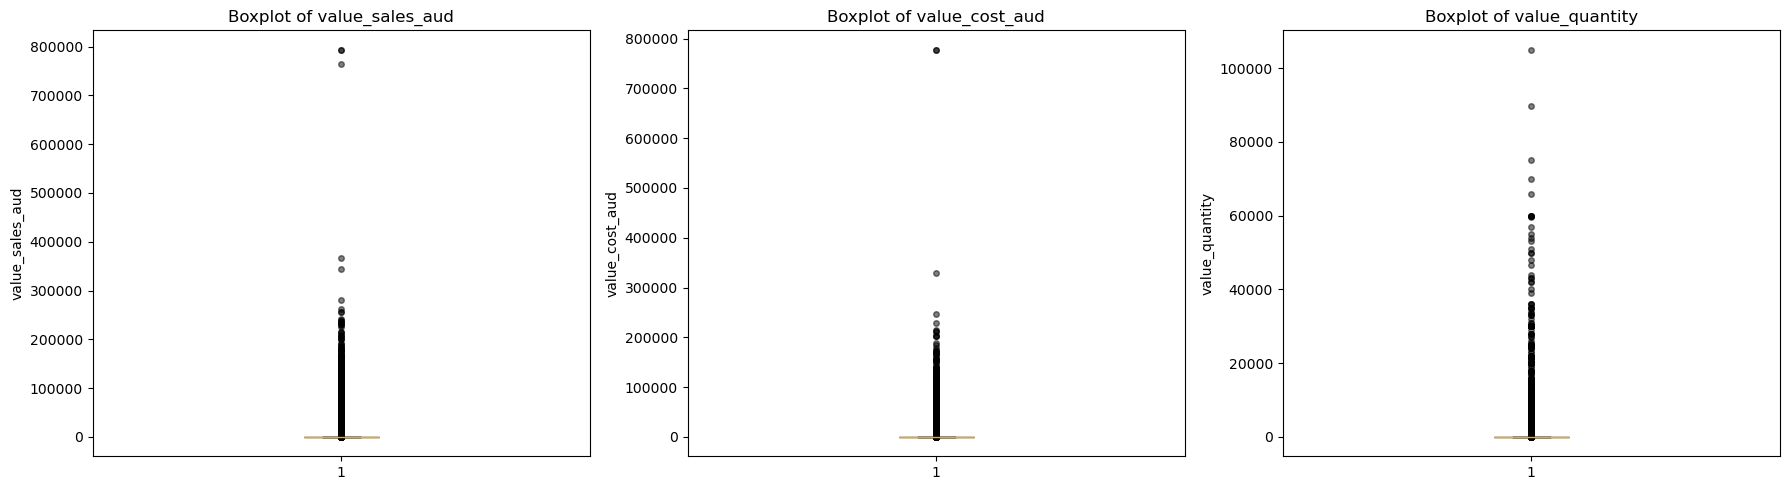

In [52]:
# Select all numeric columns except value_price_adjusment, source_year, conversion rate, and value_profit_aud
numeric_cols = ['value_sales_aud','value_cost_aud','value_quantity']

# Set the size for the canvas
plt.figure(figsize=(18, 5))

# Use for loop to draw boxplot for each item type
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor="white", color="black"),
        medianprops=dict(color="orange"),
        flierprops=dict(marker="o", markerfacecolor="black", markersize=4, alpha=0.5)
    )
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

The results revealed that **value_sales**, **value_cost**, and **value_quantity** contained a notable proportion of outliers. The distributions are heavily right-skewed, with the majority of observations concentrated at relatively low values while a small number of transactions exhibit exceptionally large amounts.

For **value_sales_aud** and **value_cost_aud**, the extreme outliers likely represent unusually large transactions, bulk purchases, commercial orders, or exceptional business activities. Similarly, the **value_quantity** column contains several transactions with extremely high quantities compared to the typical purchase behaviour observed in the dataset.

As these extreme values could distort model training, all detected outliers were subsequently imputed with the column median to preserve data integrity while minimising the influence of extreme observations.

In [53]:
# Function to count and impute outliers
def count_and_impute_outliers(df):
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier = (df[col] < lower) | (df[col] > upper)
        total = outlier.sum()
        pct = (total / len(df)) * 100
        print(f"{col} has {total} outliers ({pct:.2f}%)")

        # Replace all outliers with the column median
        median             = df[col].median()
        df.loc[outlier, col] = median

count_and_impute_outliers(df)

value_sales_aud has 221732 outliers (12.95%)
value_cost_aud has 232139 outliers (13.55%)
value_quantity has 184564 outliers (10.78%)


In [54]:
# Recalculate value_profit_aud from imputed columns
df['value_profit_aud'] = df['value_sales_aud'] - df['value_cost_aud']

## 1.13 Check Skewness

Skewness analysis was performed on all numerical columns to assess the symmetry of their distributions. A histogram was plotted for each column to visually inspect the distribution shape, followed by a quantitative skewness score. Skewness measures the degree of asymmetry in a distribution, where a value of approximately 0 indicates a normal distribution, values greater than 1 or less than -1 indicate high skewness, and values between 0.5 and 1 indicate moderate skewness.

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1712740 entries, 0 to 1988294
Data columns (total 37 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   accounting_date           datetime64[ns]
 1   fiscal_month_year         category      
 2   company_code              category      
 3   customer_code             category      
 4   customer_district_code    category      
 5   item_code                 category      
 6   business_area_code        category      
 7   item_group_code           category      
 8   item_class_code           category      
 9   item_type                 category      
 10  bonus_group_code          category      
 11  environment_group_code    category      
 12  technology_group_code     category      
 13  commission_group_code     category      
 14  reporting_classification  category      
 15  light_source              category      
 16  warehouse_code            category      
 17  abc_class_cod

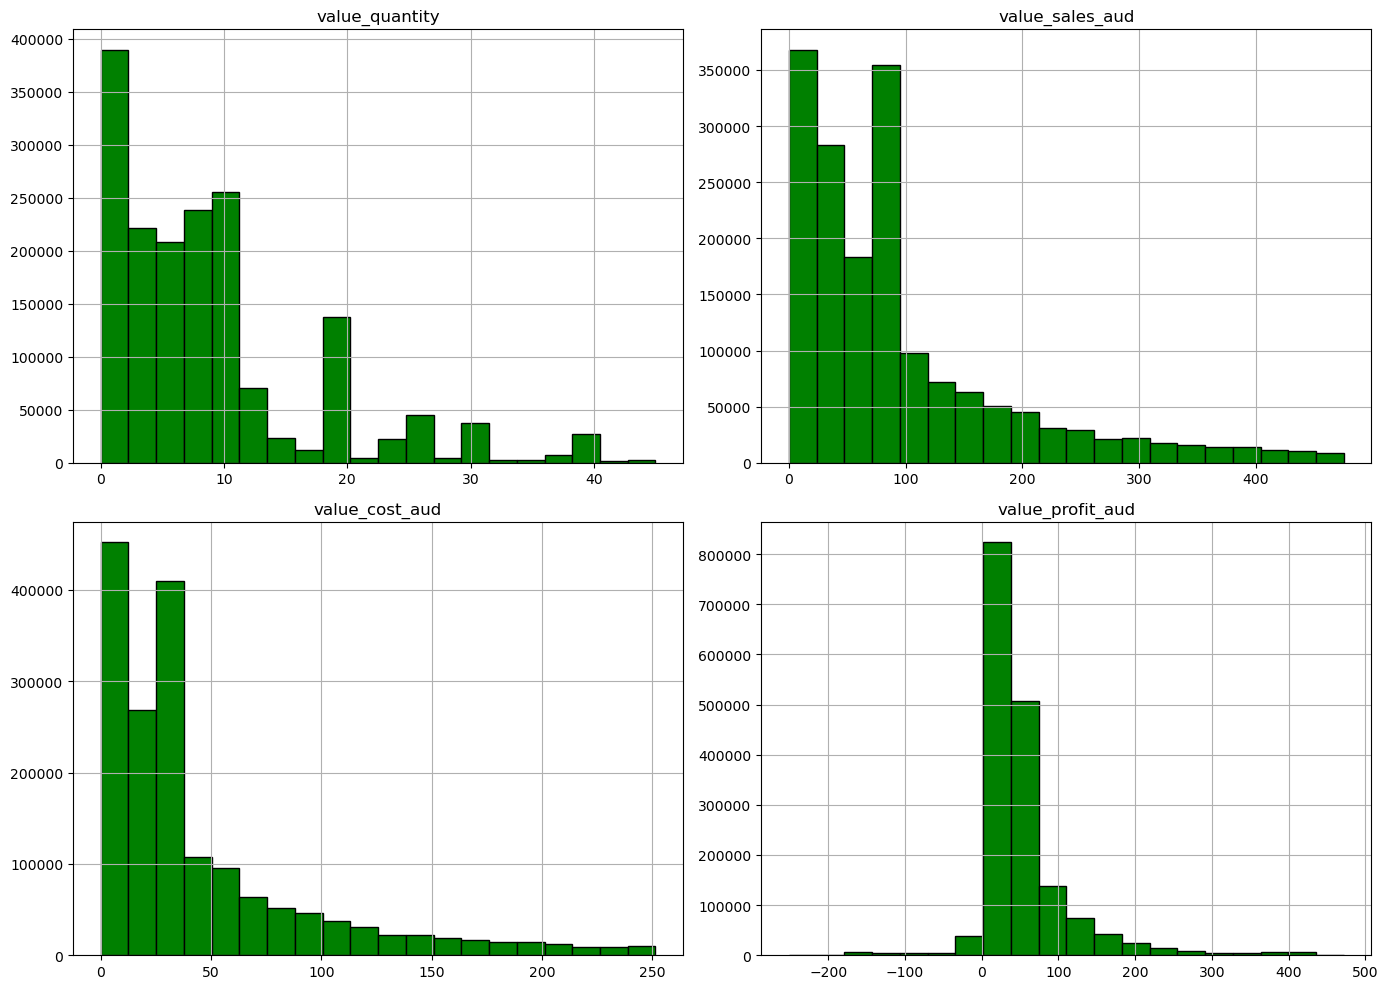

In [56]:
# Select only numerical columns except value_price_adjustment, source_year, and conversion_rate
num_cols = ['value_quantity', 'value_sales_aud', 'value_cost_aud', 'value_profit_aud']

# Histograms to check skewness of data
df[num_cols].hist(figsize=(14, 10), bins=20, edgecolor="black", color ="green")
plt.tight_layout()
plt.show()

In [57]:
# Check skewness for each column
for col in num_cols:
  print(f"{col} skewness: {df[col].skew():.3f}")

value_quantity skewness: 1.633
value_sales_aud skewness: 1.774
value_cost_aud skewness: 1.900
value_profit_aud skewness: 2.442


All numerical columns exhibit right-skewed distributions, which is consistent with typical sales transaction data where most orders are small but a minority are significantly larger. As these values are subsequently aggregated to the customer level for model training, and given that outlier imputation has already reduced extreme values, no further transformation is applied at this stage.

## 1.14 Final Check

In [58]:
# Set the option to show all columns
pd.set_option('display.max_columns', None)

df.reset_index(drop=True, inplace=True)
df

,accounting_date,fiscal_month_year,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,bonus_group_code,environment_group_code,technology_group_code,commission_group_code,reporting_classification,light_source,warehouse_code,abc_class_code,abc_class_volume,business_chain_l1_code,business_chain_l1_name,salesperson_code,order_type_code,market_segment,value_quantity,value_price_adjustment,currency,invoice_number,line_number,invoice_date,customer_order_number,order_date,source_year,conversion_rate,value_sales_aud,value_cost_aud,value_profit_aud
0,2023-03-02,2023-09,101,598961412.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,Trade,S,SYLV,NET_SALES,Discontinuing,Traditional,N0,J,J,MED,Metro Electrical Distributors,T203,NOR,Commercial & Industrial,8,0,AUD,2192463,1,2023-03-02,5679716,2023-03-02,2023,1.0,363.66,34.5492,329.1108
1,2023-02-20,2023-08,101,571401204.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,Trade,S,SYLV,NET_SALES,Discontinuing,Traditional,N0,J,J,MED,Metro Electrical Distributors,T203,NOR,Commercial & Industrial,24,0,AUD,2187048,1,2023-02-20,5669188,2023-02-20,2023,1.0,76.56,50.9136,25.6464
2,2023-02-20,2023-08,101,598961408.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,Trade,S,SYLV,NET_SALES,Discontinuing,Traditional,N0,J,J,MED,Metro Electrical Distributors,P248,EDI,Commercial & Industrial,30,0,AUD,2187133,1,2023-02-20,5670176,2023-02-20,2023,1.0,95.70,63.6420,32.0580
3,2023-02-01,2023-08,101,599001040.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,Trade,S,SYLV,NET_SALES,Discontinuing,Traditional,N0,J,J,MED,Metro Electrical Distributors,P237,EDI,Commercial & Industrial,6,0,AUD,2179206,1,2023-02-01,5654488,2023-02-01,2023,1.0,19.14,12.7284,6.4116
4,2023-02-17,2023-08,101,599001040.0,200,GENIE11WWWBC,LMP,LMP01008,LMP01,5,Trade,S,SYLV,NET_SALES,Discontinuing,Traditional,N0,J,J,MED,Metro Electrical Distributors,P237,NOR,Commercial & Industrial,6,0,AUD,2186510,1,2023-02-17,5668280,2023-02-17,2023,1.0,19.14,12.7284,6.4116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712735,2024-07-04,2025-01,101,942799824.0,400,1013240,DLT,DLT02002,DLT02,1,Professional,S,SYLV,NET_SALES,Continuing,LED,1N1,J,E,MED,Metro Electrical Distributors,T431,NOR,Commercial & Industrial,2,0,AUD,814015,0,2024-07-04,3000268,2024-07-04,2024,1.0,0.00,197.9100,-197.9100
1712736,2024-09-19,2025-03,101,1422019806.0,310,SUPHL150MHKIT2,910,230,6002,1,Professional,P,FGDFT,NET_SALES,Continuing,Accessories,1V0,J,J,MED,Metro Electrical Distributors,P327,PRO,Commercial & Industrial,8,0,AUD,2409135,1,2024-09-19,6091726,2024-08-19,2024,1.0,75.00,34.5492,40.4508
1712737,2024-07-11,2025-01,101,603200400.0,300,197110,LMP,LMP05015,LMP05,7,Trade,S,78,NET_SALES,Discontinuing,Traditional,1V0,D,J,ZZ8,EndUser Solutions,P300,NOR,Commercial & Industrial,10,0,AUD,815484,0,2024-07-11,2986126,2024-07-11,2024,1.0,29.10,20.3800,8.7200
1712738,2024-07-18,2025-01,101,603200400.0,300,197110,LMP,LMP05015,LMP05,7,Trade,S,78,NET_SALES,Discontinuing,Traditional,1V0,D,J,ZZ8,EndUser Solutions,P300,NOR,Commercial & Industrial,40,0,AUD,817123,0,2024-07-18,3008864,2024-07-18,2024,1.0,116.40,81.5200,34.8800


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1712740 entries, 0 to 1712739
Data columns (total 37 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   accounting_date           datetime64[ns]
 1   fiscal_month_year         category      
 2   company_code              category      
 3   customer_code             category      
 4   customer_district_code    category      
 5   item_code                 category      
 6   business_area_code        category      
 7   item_group_code           category      
 8   item_class_code           category      
 9   item_type                 category      
 10  bonus_group_code          category      
 11  environment_group_code    category      
 12  technology_group_code     category      
 13  commission_group_code     category      
 14  reporting_classification  category      
 15  light_source              category      
 16  warehouse_code            category      
 17  abc_clas

In [60]:
df.describe()

,accounting_date,value_quantity,value_price_adjustment,invoice_date,order_date,source_year,conversion_rate,value_sales_aud,value_cost_aud,value_profit_aud
count,1712740,1712740.0,1712740.0,1712740,1712740,1.712740e+06,1.712740e+06,1.712740e+06,1.712740e+06,1.712740e+06
mean,2023-12-16 00:14:24.484276224,9.228147,0.000127,2023-12-16 00:16:38.770157312,2023-12-12 13:21:53.692914176,2.023472e+03,1.000291e+00,9.457213e+01,4.580537e+01,4.876676e+01
min,2023-01-02 00:00:00,0.0,0.0,2023-01-02 00:00:00,2021-03-09 00:00:00,2.023000e+03,1.000000e+00,0.000000e+00,0.000000e+00,-2.513860e+02
25%,2023-06-14 00:00:00,3.0,0.0,2023-06-14 00:00:00,2023-06-12 00:00:00,2.023000e+03,1.000000e+00,2.820000e+01,1.162400e+01,1.372800e+01
50%,2023-12-03 00:00:00,8.0,0.0,2023-12-03 00:00:00,2023-11-29 00:00:00,2.023000e+03,1.000000e+00,7.500000e+01,3.454920e+01,3.568000e+01
75%,2024-06-17 00:00:00,10.0,0.0,2024-06-17 00:00:00,2024-06-12 00:00:00,2.024000e+03,1.000000e+00,1.177600e+02,5.602800e+01,5.828000e+01
max,2024-12-31 00:00:00,45.0,1.0,2024-12-31 00:00:00,2024-12-30 00:00:00,2.024000e+03,1.630000e+00,4.752000e+02,2.515265e+02,4.719100e+02
std,NaN,8.513164,0.011281,NaN,NaN,4.992246e-01,1.248702e-02,9.565104e+01,5.020796e+01,6.346562e+01


## 1.15 Building the Customer-Level Churn Dataset (churn_df)

The cleaned transaction dataset contains one row per transaction, with a single customer potentially appearing hundreds of times across the observation period. To support customer retention analysis and customer-level insight generation, the data must be aggregated to one row per customer, which summarise each customer's full 2023 purchasing behaviour into a set of meaningful behavioural features.

Churn is defined as follows:
*   CHURNED (1): A customer who was active in the 2023 source file but placed zero orders in the 2024 source file.
*   RETAINED (0): A customer who was active in both periods.

Customers who appeared for the first time in 2024 are excluded, as they have no 2023 behavioural history to learn from.

This customer-level dataset, churn_df, serves as the foundation for all subsequent sections.




In [61]:
# Step 1: Identify 2023 and 2024 customer group
cust_2023       = set(df.loc[df["source_year"]==2023, "customer_code"].dropna().unique())
cust_2024       = set(df.loc[df["source_year"]==2024, "customer_code"].dropna().unique())
n_new_cust_2024 = len(cust_2024 - cust_2023) # new cust in 2024 only

# Step 2: Isolate 2023 transactions
tx23          = df[df["source_year"]==2023].copy()
tx23["month"] = tx23["accounting_date"].dt.month # extract month only

# Step 3: Aggregate per-customer behavioural features
churn_df = tx23.groupby("customer_code", observed=True).agg(
    total_spend         = ("value_sales_aud", "sum"),
    total_profit        = ("value_profit_aud", "sum"),
    avg_txn_value       = ("value_sales_aud", "mean"),
    n_transactions      = ("value_sales_aud", "count"),
    n_months_active     = ("month", "nunique"),
    total_quantity      = ("value_quantity", "sum"),
    n_business_areas    = ("business_area_code", "nunique"),
    n_distinct_items    = ("item_code", "nunique"),
    n_distinct_salesppl = ("salesperson_code", "nunique"),
    last_purchase       = ("accounting_date", "max"),
    first_purchase      = ("accounting_date", "min"),
).reset_index()

# Step 4: Recency and tenure
churn_df["last_purchase"]  = pd.to_datetime(churn_df["last_purchase"])
churn_df["first_purchase"] = pd.to_datetime(churn_df["first_purchase"])

# Reference date = last transaction in 2023 observation window
reference_date = tx23["accounting_date"].max()
# Recency means days before year-end a customer last purchased
churn_df["recency_days"] = (reference_date - churn_df["last_purchase"]).dt.days
# Tenure means span between first and last 2023 purchase
churn_df["tenure_days"]  = (churn_df["last_purchase"] - churn_df["first_purchase"]).dt.days

# Step 5: Average margin
# Proportion of revenue retained as profit
churn_df["avg_margin"] = np.where(
    churn_df["total_spend"] > 0, # to avoid division by 0
    churn_df["total_profit"] / churn_df["total_spend"],
    0
)

# Step 6: Map primary district to readable name
DISTRICT_NAMES = {
    "200":"Sydney",          "300":"Melbourne",       "400":"Brisbane",
    "500":"Adelaide",        "600":"Perth",            "410":"Townsville",
    "310":"Tasmania",        "210":"ACT/Riverina",     "510":"Darwin",
    "520":"Inlite NZ",       "530":"South Is. NZ",     "535":"Central NZ",
    "540":"Northern NZ",     "710":"Head Office Sales",
    "720":"Intercompany Sales", "545":"Head Office NZ"
}

# Find the most frequently occurring district code per customer
dist_primary = (
    tx23.groupby(["customer_code", "customer_district_code"], observed=True)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .drop_duplicates(subset="customer_code")
        .set_index("customer_code")["customer_district_code"]
)

# Mapping customer → district code → district name
churn_df["district_name"] = (churn_df["customer_code"]
                                .map(dist_primary)
                                .map(DISTRICT_NAMES)
                                .fillna("Other")) # if not recognize, put Other

# Step 7: Target variable
# Churned = 1 if customer did not return in 2024, else Retained = 0
churn_df["churned"] = (~churn_df["customer_code"].isin(cust_2024)).astype(int)

# Step 8: Drop first_purchase (already captured by tenure_days)
churn_df = churn_df.drop(columns=["first_purchase"])

# Step 9: Replace infinite values before imputation
churn_df = churn_df.replace([np.inf, -np.inf], np.nan)

# Step 10: Impute missing values
# Numerical columns → median
num_cols = [
    "total_spend", "total_profit", "avg_txn_value", "avg_margin",
    "n_transactions", "n_months_active", "total_quantity",
    "n_business_areas", "n_distinct_items", "n_distinct_salesppl",
    "recency_days", "tenure_days"
]
for col in num_cols:
    churn_df[col] = churn_df[col].fillna(churn_df[col].median())

# Categorical columns → mode
cat_cols = [c for c in churn_df.select_dtypes(include=["object","category"]).columns
            if c != "customer_code"] # exclude customer ID
for col in cat_cols:
    churn_df[col] = churn_df[col].fillna(churn_df[col].mode()[0])

# Step 11: Define modelling feature list
modelling_features = [
    "total_spend", "total_profit", "avg_txn_value", "avg_margin",
    "n_transactions", "n_months_active", "total_quantity",
    "n_business_areas", "n_distinct_items", "n_distinct_salesppl",
    "recency_days", "tenure_days", "district_name"
]

# Summary
n_retained = (churn_df["churned"]==0).sum()
n_churned  = (churn_df["churned"]==1).sum()

print(f"Customer cohort : {len(churn_df):,}")
print(f"  Retained      : {n_retained:,} ({n_retained/len(churn_df)*100:.1f}%)")
print(f"  Churned       : {n_churned:,}  ({n_churned/len(churn_df)*100:.1f}%)")
print(f"  New in 2024   : {n_new_cust_2024:,}")
print(f"\nData window     : {tx23['accounting_date'].min().date()} → "
      f"{tx23['accounting_date'].max().date()}")
print(f"Reference date  : {reference_date.date()}")
print(f"\nchurn_df shape  : {churn_df.shape}")
print(f"Modelling features ({len(modelling_features)}): {modelling_features}")

Customer cohort : 3,070
  Retained      : 2,691 (87.7%)
  Churned       : 379  (12.3%)
  New in 2024   : 383

Data window     : 2023-01-02 → 2023-12-31
Reference date  : 2023-12-31

churn_df shape  : (3070, 16)
Modelling features (13): ['total_spend', 'total_profit', 'avg_txn_value', 'avg_margin', 'n_transactions', 'n_months_active', 'total_quantity', 'n_business_areas', 'n_distinct_items', 'n_distinct_salesppl', 'recency_days', 'tenure_days', 'district_name']


In [62]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3070 entries, 0 to 3069
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_code        3070 non-null   category      
 1   total_spend          3070 non-null   float64       
 2   total_profit         3070 non-null   float64       
 3   avg_txn_value        3070 non-null   float64       
 4   n_transactions       3070 non-null   int64         
 5   n_months_active      3070 non-null   int64         
 6   total_quantity       3070 non-null   Int64         
 7   n_business_areas     3070 non-null   int64         
 8   n_distinct_items     3070 non-null   int64         
 9   n_distinct_salesppl  3070 non-null   int64         
 10  last_purchase        3070 non-null   datetime64[ns]
 11  recency_days         3070 non-null   int64         
 12  tenure_days          3070 non-null   int64         
 13  avg_margin           3070 non-nul

In [63]:
# Convert total_quantity data type to int64
churn_df['total_quantity'] = churn_df['total_quantity'].astype('int64')

In [64]:
churn_df.describe()

,total_spend,total_profit,avg_txn_value,n_transactions,n_months_active,total_quantity,n_business_areas,n_distinct_items,n_distinct_salesppl,last_purchase,recency_days,tenure_days,avg_margin,churned
count,3.070000e+03,3.070000e+03,3070.000000,3070.000000,3070.000000,3070.000000,3070.000000,3070.000000,3070.000000,3070,3070.000000,3070.000000,3070.000000,3070.000000
mean,2.765883e+04,1.419952e+04,96.497955,294.478176,8.739088,2721.168730,7.606189,122.746580,1.740717,2023-11-10 13:43:39.674267136,50.428013,268.981107,0.499568,0.123453
min,0.000000e+00,-4.814075e+03,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2023-01-04 00:00:00,0.000000,0.000000,-24.359997,0.000000
25%,1.643290e+03,8.564423e+02,66.281483,19.250000,5.000000,180.000000,3.000000,13.000000,1.000000,2023-11-14 06:00:00,11.000000,235.250000,0.493241,0.000000
50%,9.678285e+03,5.127929e+03,94.759513,142.000000,12.000000,1236.000000,7.000000,76.000000,1.000000,2023-12-17 00:00:00,14.000000,335.000000,0.522872,0.000000
75%,3.790435e+04,1.929560e+04,121.808392,425.750000,12.000000,3651.750000,12.000000,173.000000,2.000000,2023-12-20 00:00:00,46.750000,347.750000,0.562141,0.000000
max,3.497315e+06,1.770169e+06,449.645000,30808.000000,12.000000,299080.000000,20.000000,6136.000000,5.000000,2023-12-31 00:00:00,361.000000,362.000000,1.000000,1.000000
std,7.499527e+04,3.800302e+04,49.671845,677.610619,4.146079,6622.617292,4.907116,175.585312,0.828699,NaN,74.277560,117.906070,0.595777,0.329010


The churn_df dataset contains 3,070 customers with no missing values across all 16 columns, confirming that the imputation steps in Section 1.15 were effective. The churn rate stands at 12.3% (mean of churned = 0.123), representing 379 customers who did not return in 2024. All count-based features, such as **n_transactions**, **n_months_active**, **n_business_areas**, **n_distinct_items**, and **n_distinct_salesppl** show a minimum of 1, confirming no customers slipped through the aggregation with zero activity. Features that can legitimately be zero, such as **total_spend**, **total_quantity**, and **tenure_days** reflect edge cases such as service-only transactions and customers whose first and last purchase occurred on the same day, both of which are valid business scenarios.

The spread of key features reveals considerable customer heterogeneity. **recency_days** ranges from 0 to 361, with a mean of 50 days, suggesting a meaningful gap in last-purchase timing between active and lapsed customers. **tenure_days** averages 269 days, indicating most retained customers engaged consistently throughout the year, while a minimum of 0 points to single-day burst buyers. **avg_margin** ranges from −24.36 to 1.0, with negative values representing customers whose orders were fulfilled below cost. These are retained in the model as they reflect genuine account behaviour. The wide range in **n_transactions** (1 to 30,808) and **total_spend** ($0 to $3.5M) reflects LuminaTech's diverse customer base, from small occasional buyers to large high-frequency accounts, all of which the model must distinguish when predicting churn.

### Section 2: Exploratory Insights (all the codes in one cell - do not insert extra cells)
Developed five key exploratory insights from the dataset using data visualisation techniques. Each insight was supported by an appropriate chart or graph and accompanied by a detailed interpretation of the findings. The analysis focused on identifying meaningful business patterns, trends, and opportunities within the data. For every insight, recommendations were provided to demonstrate its strategic value and relevance to management decision-making.

Examples of insights explored included:

- Customer retention and churn patterns
- Sales performance and seasonal trends
- Profitability across customer segments or locations
- Product category performance
- Factors influencing revenue and profit margins

Each visualisation was designed to communicate findings clearly and support data-driven business decisions.

### 2.1 Monthly Revenue and Customer Activity Trend

*   **Data source:** (cleaned) df
*   **Objective:** To analyse whether changes in monthly revenue are associated with changes in customer activity over time. This analysis helps identify whether periods of higher customer engagement correspond to increased revenue generation and provides insight into overall business performance trends.



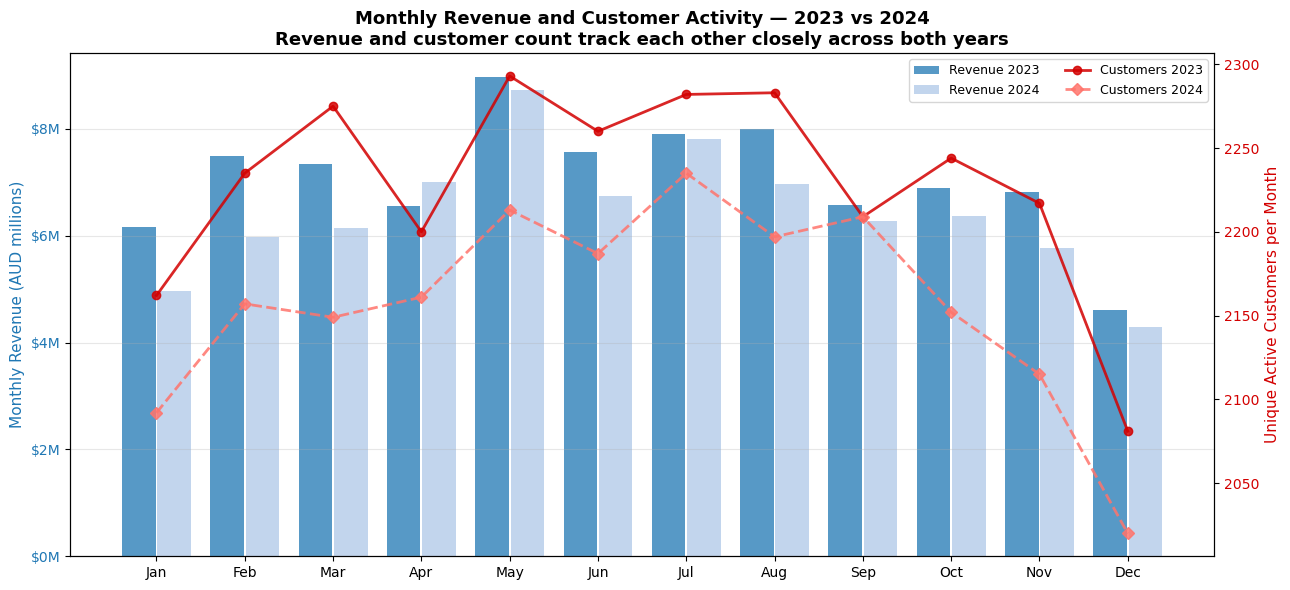

Total revenue — 2023: $84.9M  |  2024: $77.1M  |  YoY: -9.2%


In [65]:
# Step 1: Prepare monthly aggregates
# Exclude zero-value transactions (service fees) from revenue calculation
pos = df[df["value_sales_aud"] > 0].copy()
pos["month"] = pos["accounting_date"].dt.month

months = list(range(1, 13))
mlabels = ["Jan","Feb","Mar","Apr","May","Jun",
           "Jul","Aug","Sep","Oct","Nov","Dec"]

# Group by source year and month
rev_23 = pos[pos["source_year"]==2023].groupby("month")["value_sales_aud"].sum().div(1e6)
rev_24 = pos[pos["source_year"]==2024].groupby("month")["value_sales_aud"].sum().div(1e6)
cust_23 = pos[pos["source_year"]==2023].groupby("month")["customer_code"].nunique()
cust_24 = pos[pos["source_year"]==2024].groupby("month")["customer_code"].nunique()

# Fill missing months with 0
r23 = [rev_23.get(m, 0)  for m in months]
r24 = [rev_24.get(m, 0)  for m in months]
c23 = [cust_23.get(m, 0) for m in months]
c24 = [cust_24.get(m, 0) for m in months]

# Step 2: Plot
fig, ax1 = plt.subplots(figsize=(13, 6))

# Revenue bars — left axis
ax1.bar([m - 0.2 for m in months], r23, width=0.38,
        color="#1f77b4", alpha=0.75, label="Revenue 2023")
ax1.bar([m + 0.2 for m in months], r24, width=0.38,
        color="#aec7e8", alpha=0.75, label="Revenue 2024")
ax1.set_ylabel("Monthly Revenue (AUD millions)", color="#1f77b4", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax1.set_xticks(months)
ax1.set_xticklabels(mlabels)
ax1.grid(axis="y", alpha=0.3)

# Unique customer lines — right axis
ax2 = ax1.twinx()
ax2.plot(months, c23, "o-",  color="#d30000", lw=2, markersize=6,
         alpha=0.85, label="Customers 2023")
ax2.plot(months, c24, "D--", color="#ff746c", lw=2, markersize=6,
         alpha=0.85, label="Customers 2024")
ax2.set_ylabel("Unique Active Customers per Month", color="#d30000", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#d30000")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper right", ncol=2, fontsize=9)

ax1.set_title("Monthly Revenue and Customer Activity — 2023 vs 2024\n"
              "Revenue and customer count track each other closely across both years",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Step 3: Summary
yoy = (sum(r24) - sum(r23)) / sum(r23) * 100 if sum(r23) > 0 else 0
print(f"Total revenue — 2023: ${sum(r23):.1f}M  |  2024: ${sum(r24):.1f}M  |  YoY: {yoy:+.1f}%")

**INSIGHT:** <br>
Monthly revenue in 2023 peaked in May at approximately \$8M before gradually declining through the second half of the year. The 2024 trend follows a similar seasonal shape but at a consistently lower level across most months, resulting in a year-on-year revenue decline of −9.2% (\$84.9M in 2023 vs $77.1M in 2024). <br>
Notably, the customer count (right axis) mirrors the revenue pattern almost exactly in both years. When revenue dips, active customers dip in tandem, and vice versa. This lockstep relationship confirms that revenue is driven by customer volume rather than changes in average spend per customer.

**VALUE TO MANAGEMENT**:<br>
The −9.2% revenue decline between 2023 and 2024 is a significant business signal. Since customer count and revenue move together, the decline is almost certainly explained by fewer active customers and not by customers spending less per order. <br>
This directly motivates the churn analysis in Sections 3 and 4, which is to understand which customers stopped transacting and why is the first step toward reversing the revenue trend. The May peak visible in both years also suggests a seasonal demand cycle, which management could exploit through targeted pre-season promotions to maximise revenue during the natural high-demand window.

### 2.2 Recency vs Transaction Frequency: Identifying At-Risk Customers
*   **Data source:** churn_df
*   **Objective:** To examine whether churned and retained customers demonstrate different behavioural patterns based on their purchase recency and transaction frequency. This analysis helps identify customer groups that may be at higher risk of churn by comparing how recently and how frequently they made transactions.

In [1]:
# Section 2.1 — Dual-axis line chart: monthly revenue and unique customers
# Data source: cleaned df (transaction level — 1.98M rows)
pos = df[df["sales_aud"] > 0].copy()
pos["month"] = pos["accounting_date"].dt.month
months  = list(range(1,13))
mlabels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
rev  = pos.groupby(["year","month"])["sales_aud"].sum().div(1e6).reset_index()
cust = pos.groupby(["year","month"])["customer_code"].nunique().reset_index()
r23 = rev[rev["year"]==2023]["sales_aud"].values
r24 = rev[rev["year"]==2024]["sales_aud"].values
c23 = cust[cust["year"]==2023]["customer_code"].values
c24 = cust[cust["year"]==2024]["customer_code"].values

fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.plot(months, r23, "o-",  color="#1f77b4", lw=2.5, markersize=6, label="Revenue 2023")
ax1.plot(months, r24, "s--", color="#aec7e8", lw=2.5, markersize=6, label="Revenue 2024")
ax1.fill_between(months, r23, r24, where=[r24[i]<r23[i] for i in range(12)],
                 alpha=0.12, color="#d62728", label="Revenue gap (2024 < 2023)")
ax1.set_ylabel("Monthly Revenue (AUD millions)", color="#1f77b4", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_xticks(months); ax1.set_xticklabels(mlabels)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f"${x:.0f}M"))
ax2 = ax1.twinx()
ax2.plot(months, c23, "^-",  color="#2ca02c", lw=2, markersize=6, alpha=0.85, label="Customers 2023")
ax2.plot(months, c24, "D--", color="#98df8a", lw=2, markersize=6, alpha=0.85, label="Customers 2024")
ax2.set_ylabel("Unique Customers per Month", color="#2ca02c", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#2ca02c")
lines1,labels1 = ax1.get_legend_handles_labels()
lines2,labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right", ncol=2, fontsize=9)
ax1.set_title("Monthly Revenue and Active Customers — 2023 vs 2024\nBoth revenue and customer activity declined, framing the churn problem",
              fontsize=13, fontweight="bold")
ax1.grid(alpha=0.3)
plt.tight_layout(); plt.show()

yoy_rev  = (sum(r24)-sum(r23))/sum(r23)*100
yoy_cust = (c24.mean()-c23.mean())/c23.mean()*100
print(f"YoY revenue change:          {yoy_rev:+.1f}%")
print(f"YoY avg monthly customers:   {yoy_cust:+.1f}%")
print(f"Peak month 2023: {mlabels[r23.argmax()]} ${r23.max():.1f}M  |  2024: {mlabels[r24.argmax()]} ${r24.max():.1f}M")
print("\nINSIGHT: Revenue and customer activity declined in lockstep — the problem is not")
print("smaller orders but fewer active customers. This is the business case for Section 4.")
print("VALUE TO MANAGEMENT: The gap is largest in H1. Retention campaigns running in Q4")
print("of the prior year would target the highest-risk period proactively.")


NameError: name 'df' is not defined

**INSIGHT:** <br>
The scatter plot reveals two clearly separated clusters. Retained customers (green) are densely concentrated on the left, which shows low recency and high transaction frequency. It means that they purchased frequently and recently throughout 2023. Churned customers (red) are spread to the right, beyond the 83-day threshold, with far fewer transactions. The separation is quantified strikingly: 86.3% of churned customers exceeded the 75th percentile recency threshold, compared to only 16.4% of retained customers. The mean recency gap confirms that retained customers last purchased an average of 34 days before year-end, while churned customers had already stopped transacting 169 days earlier. Transaction frequency reinforces the same idea that retained customers averaged 332 orders versus just 28 for churned customers, which is a twelvefold difference.

**VALUE TO MANAGEMENT**:<br>
The 83-day recency threshold acts as a practical, data-driven early-warning signal. A customer who has not placed an order in more than 83 days has historically an 86.3% probability of not returning, making this a highly reliable churn indicator. Management can operationalise this immediately by building an automated alert that flags any previously active account crossing the 83-day inactivity mark for proactive sales team outreach before the relationship is fully lost.



### 2.3 Behavioural Distribution: Churned vs Retained Customers

*   **Data source**: churn_df
*   **Objective:** To compare the distribution of key behavioural features between churned and retained customers. This analysis helps identify whether customer groups exhibit different purchasing behaviours in terms of recency, activity level, tenure, and transaction value, which may contribute to churn risk

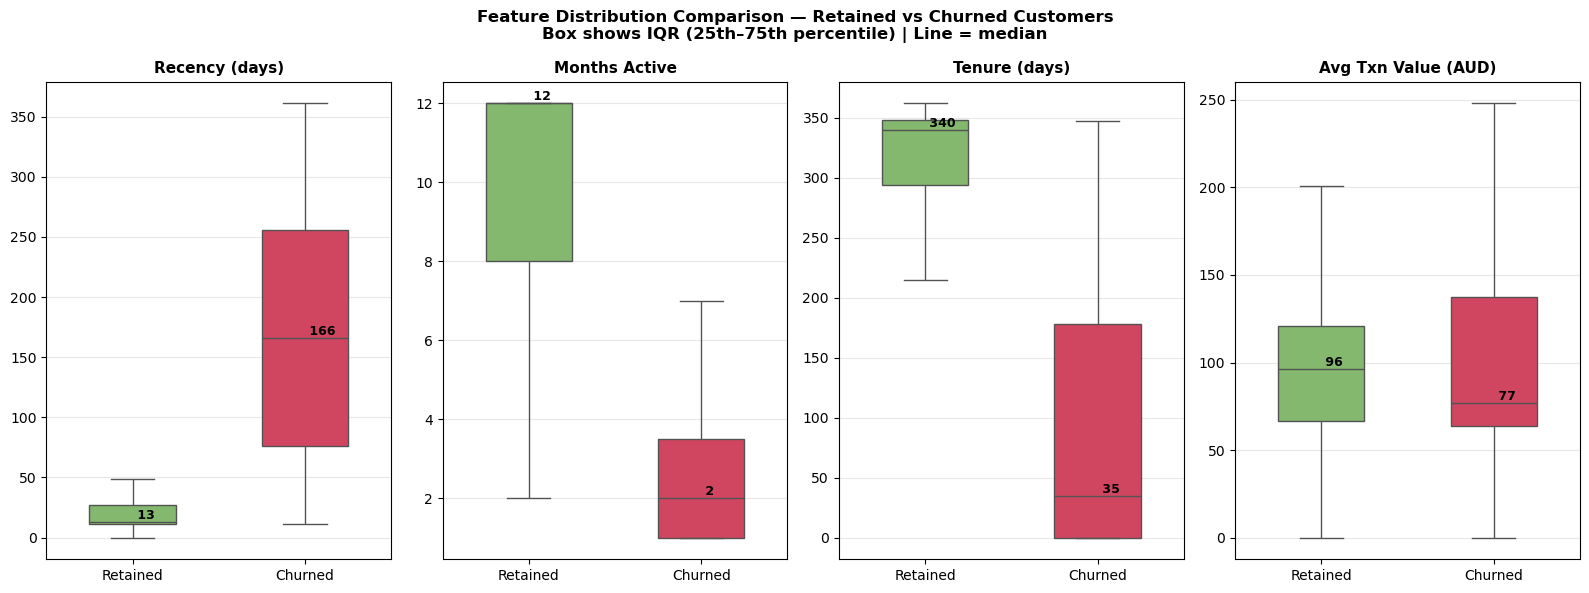

Recency (days)            Retained median:     13.0  |  Churned median:    166.0
Months Active             Retained median:     12.0  |  Churned median:      2.0
Tenure (days)             Retained median:    340.0  |  Churned median:     35.0
Avg Txn Value (AUD)       Retained median:     96.0  |  Churned median:     76.7


In [67]:
# Step 1: Select feature to compare
features   = ["recency_days", "n_months_active", "tenure_days", "avg_txn_value"]
f_labels   = ["Recency (days)", "Months Active", "Tenure (days)", "Avg Txn Value (AUD)"]
palette    = {0: "#2ca02c", 1: "#d62728"}
group_labs = {0: "Retained", 1: "Churned"}

plot_df         = churn_df[features + ["churned"]].copy()
plot_df["Group"] = plot_df["churned"].map(group_labs)

# Step 2: Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for i, (feat, label) in enumerate(zip(features, f_labels)):
    sns.boxplot(
        data      = plot_df,
        x         = "Group",
        y         = feat,
        palette   = {"Retained": "#7dc462", "Churned": "#e72f52"},
        showfliers = False, # hide extreme outliers for clarity
        width      = 0.5,
        ax         = axes[i]
    )
    axes[i].set_title(label, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(axis="y", alpha=0.3)

    # Annotate median values above each box
    for j, group in enumerate(["Retained", "Churned"]):
        median = plot_df[plot_df["Group"]==group][feat].median()
        axes[i].text(j, median, f" {median:.0f}",
                     ha="left", va="bottom", fontsize=9, fontweight="bold")

fig.suptitle("Feature Distribution Comparison — Retained vs Churned Customers\n"
             "Box shows IQR (25th–75th percentile) | Line = median",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Step 3: Summary
retained_g = plot_df[plot_df["Group"]=="Retained"]
churned_g  = plot_df[plot_df["Group"]=="Churned"]
for feat, label in zip(features, f_labels):
    print(f"{label:<25} Retained median: {retained_g[feat].median():>8.1f}  |  "
          f"Churned median: {churned_g[feat].median():>8.1f}")

**INSIGHT:**<br>
The box plots reveal dramatic distributional differences between churned and retained customers across all four features. The most striking gap is in recency where retained customers made their last purchase a median of just 13 days before year-end, while churned customers stopped buying a median of 166 days earlier, a thirteen-fold difference. Months active tells a similar story where retained customers purchased across a median of 12 distinct months (the full year), while churned customers were active in just 2 months, confirming a burst-and-exit pattern rather than a recurring habit. Tenure reinforces that retained customers maintained a purchasing span of 340 days compared to only 35 days for churned customers. Average transaction value is the exception. The gap is modest (\$96 vs \$76.7).

**VALUE TO MANAGEMENT:**<br>
These four box plots make a clear case that churn is a behavioural pattern, not a spending pattern. A customer who buys across many months with low recency is structurally different from one who makes purchases in a short burst and disappears, and this difference is identifiable well before year-end. Management can use the median benchmarks as practical monitoring thresholds: any active account with recency approaching 13 days without a new order, or confined to fewer than 3 active months, should be flagged for account manager follow-up. These are data-derived benchmarks, not arbitrary rules.



## 2.4 Churn Rate by Customer District

*   **Data source:** churn_df
*   **Objective:** To analyse whether customer churn rates differ across geographical districts. This analysis helps identify locations with disproportionately high churn rates and provides insight into whether churn risk is geographically concentrated within specific regions.

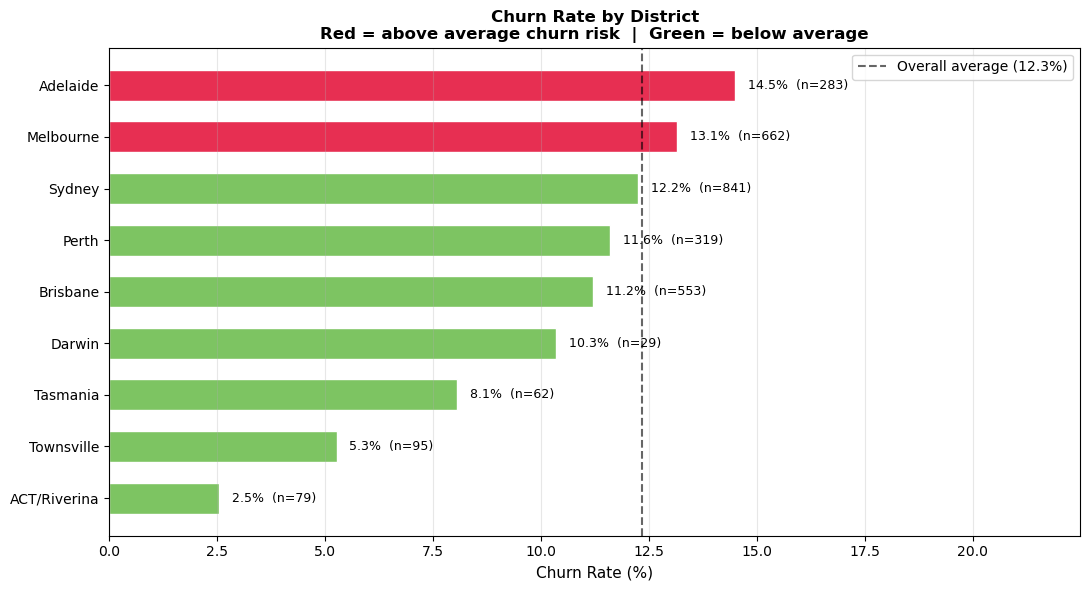

Overall churn rate: 12.3%

Highest churn districts:
  Adelaide             14.5%  (n=283)
  Melbourne            13.1%  (n=662)
  Sydney               12.2%  (n=841)

Lowest churn districts:
  ACT/Riverina         2.5%  (n=79)
  Townsville           5.3%  (n=95)
  Tasmania             8.1%  (n=62)


In [68]:
# Step 1: Aggregate churn rate per district
EXCLUDE = ["Head Office Sales", "Intercompany Sales", "Head Office NZ", "Other"]
dist_df = (churn_df[~churn_df["district_name"].isin(EXCLUDE)]
           .groupby("district_name")
           .agg(total  = ("churned", "count"),
                churned_n = ("churned", "sum"))
           .reset_index())
dist_df["churn_pct"] = dist_df["churned_n"] / dist_df["total"] * 100
dist_df = dist_df[dist_df["total"] >= 5] # exclude tiny districts
dist_df = dist_df.sort_values("churn_pct") # ascending for readability

overall = churn_df["churned"].mean() * 100

# Step 2: Plot
fig, ax = plt.subplots(figsize=(11, 6))

# Colour each bar based on whether it exceeds the overall churn rate
colors = ["#e72f52" if v >= overall else "#7dc462"
          for v in dist_df["churn_pct"]]

bars = ax.barh(dist_df["district_name"], dist_df["churn_pct"],
               color=colors, edgecolor="white", height=0.6)

# Annotate each bar with churn % and customer count
for bar, (_, row) in zip(bars, dist_df.iterrows()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{row['churn_pct']:.1f}%  (n={int(row['total'])})",
            va="center", fontsize=9)

# Overall average reference line
ax.axvline(overall, color="black", linestyle="--", lw=1.5, alpha=0.6,
           label=f"Overall average ({overall:.1f}%)")

ax.set_xlabel("Churn Rate (%)", fontsize=11)
ax.set_title("Churn Rate by District\n"
             "Red = above average churn risk  |  Green = below average",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, dist_df["churn_pct"].max() + 8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Step 3: Summary
high = dist_df.sort_values("churn_pct", ascending=False).head(3)
low  = dist_df.sort_values("churn_pct").head(3)
print(f"Overall churn rate: {overall:.1f}%\n")
print("Highest churn districts:")
for _, r in high.iterrows():
    print(f"  {r['district_name']:<20} {r['churn_pct']:.1f}%  (n={int(r['total'])})")
print("\nLowest churn districts:")
for _, r in low.iterrows():
    print(f"  {r['district_name']:<20} {r['churn_pct']:.1f}%  (n={int(r['total'])})")

**INSIGHT:**<br>
Churn risk is not uniformly distributed across LuminaTech's territory, ranging from 2.5% in ACT/Riverina to 14.5% in Adelaide, against an overall average of 12.3%. Three districts exceed the average: Adelaide (14.5%), Melbourne (13.1%), and Sydney (12.2%). Sydney and Melbourne are LuminaTech's two largest customer bases by volume (n=841 and n=662 respectively), meaning their above-average churn rates represent the greatest absolute number of lost customers. At the other end, ACT/Riverina, Townsville (5.3%), and Tasmania (8.1%) all perform well below average, where ACT/Riverina retaining 97.5% of its customers.

**VALUE TO MANAGEMENT:**<br>
The geographic variation suggests churn is partly driven by district-level factors such as local competition, account management quality, or regional economic conditions. A uniform national retention strategy is therefore inefficient. Management should prioritise targeted intervention in Adelaide, Melbourne, and Sydney which together account for the majority of churned customers in absolute terms. Equally, investigating what ACT/Riverina and Townsville are doing differently may surface replicable best practices for higher-churn regions.

## 2.5 Feature Correlation Matrix

*   **Data source:** churn_df
*   **Objective:** To examine the relationships between customer behavioural features and identify which variables are most strongly associated with churn. This analysis also helps detect potential multicollinearity between features, where highly correlated variables may contain overlapping information and reduce modelling efficiency.

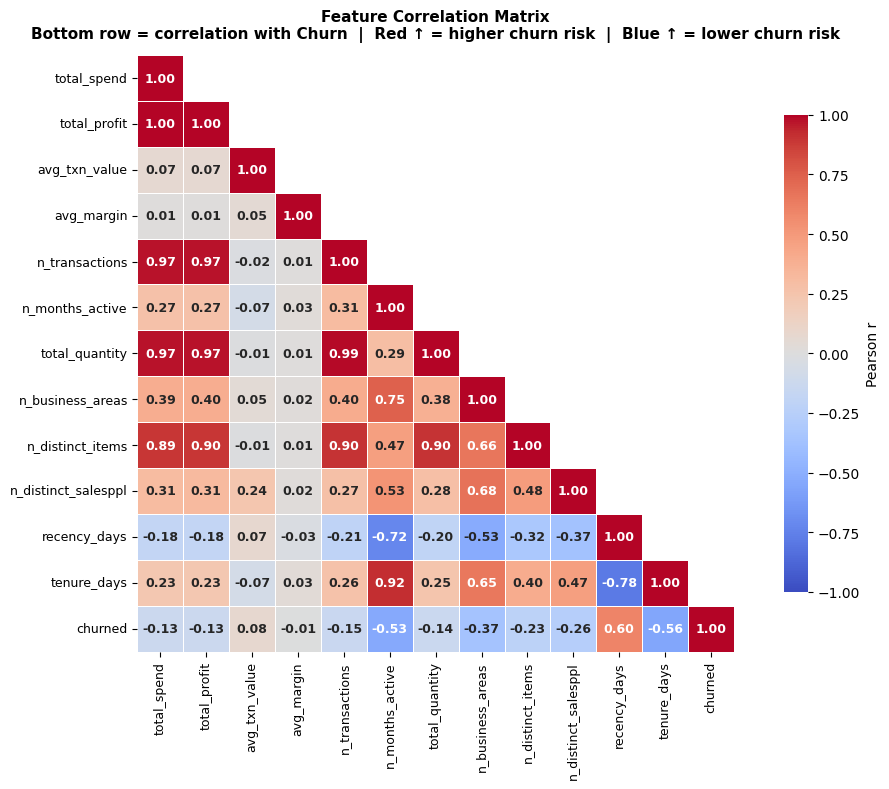

In [69]:
# Step 1: Select features and compute correlation matrix
feat_cols = [c for c in modelling_features + ["churned"]
             if churn_df[c].dtype in ["int64","float64","Int64"]]

# Calculate correlation matrix
corr   = churn_df[feat_cols].corr()

# Lower triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Step 2: Plot
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={"size": 9, "weight": "bold"},
    cbar_kws={"label": "Pearson r", "shrink": 0.8},
    ax=ax
)
ax.set_title(
    "Feature Correlation Matrix\n"
    "Bottom row = correlation with Churn  |  "
    "Red ↑ = higher churn risk  |  Blue ↑ = lower churn risk",
    fontsize=11, fontweight="bold", pad=12
)
ax.tick_params(axis="both", labelsize=9)
plt.tight_layout()
plt.show()

**INSIGHT:** <br>
The correlation matrix reveals three clear findings. First, **recency_days** has the strongest positive correlation with churn (+0.54). It means the longer a customer went without purchasing, the more likely they churned. Second, **tenure_days** (−0.53) and **n_months_active** (−0.50) are the strongest protective factors. It means that customers who engaged consistently across a longer period were significantly less likely to leave. Third, the volume-based features such as **total_spend**, **total_profit**, **n_transactions**, **total_quantity**, and **n_distinct_items** are all nearly perfectly intercorrelated with each other (r = 0.89–1.00), yet show only weak individual correlations with churn (−0.14 to −0.25). This means they are largely measuring the same underlying behaviour (how much a customer bought) while providing limited additional signal for predicting whether they will return.

**VALUE TO MANAGEMENT:** <br>
This matrix serves as a feature selection guide for the prediction model in Section 4. Including all volume-based features simultaneously adds no predictive value and inflates model complexity that will be check with VIF in Section 4 to confirm this multicollinearity and justify dropping redundant features. For management, the key takeaway is that how recently and how consistently a customer bought are far stronger predictors of loyalty than how much they spent. Retention programmes should therefore monitor engagement frequency and recency, and not just revenue, as the primary health indicators of a customer relationship.


### Section 3: Test Sub Sample Differences (all the codes in one cell - do not insert extra cells)
Developed three business-focused research questions to evaluate differences between two independent groups using two-sample t-tests. The analysis aimed to determine whether observed differences were statistically significant and provide actionable insights for management decision-making.

### 3.1 Test whether customers who churned had already stopped purchasing earlier (higher recency days) in the observation period compared to those who returned

*   **Data source:** churn_df
*   **Objective:** To determine whether churned customers have a significantly higher number of recency days compared to retained customers. In other words, to test whether customers who stopped purchasing had a longer gap since their last transaction, which would confirm that recency is a meaningful indicator of customer churn for LuminaTech Lighting's management team.

#### **Two-sample upper-tailed t-test**

**Step 1: State the Null Hypothesis and the Alternative Hypothesis**

*Null Hypothesis (H₀):* Churned customers do not have higher recency days than retained customers (μ_churned ≤ μ_retained).

*Alternative Hypothesis (Hₐ):* Churned customers have significantly higher recency days than retained customers (μ_churned > μ_retained).

**Step 2: Choose a Significance Level**

A significance level of α = 0.05 (5%) is applied.

Descriptive Statistics
──────────────────────────────────────────────────
  Retained : n=2,691  mean=33.7d  median=13d  std=51.2d
  Churned  : n=379  mean=169.2d  median=166d  std=100.2d

Levene's Test for Equality of Variances
──────────────────────────────────────────────────
  stat = 543.968,  p = 0.0000
  → Variances are significantly unequal (p < 0.05).
  → Welch's t-test (equal_var=False) applied.

Welch's t-test Results  (Hₐ: μ_churned > μ_retained)
──────────────────────────────────────────────────
  t-statistic     = 25.849
  p-value         = 4.032e-88  (one-tailed)
  Mean difference = 135.5 days  (churned − retained)


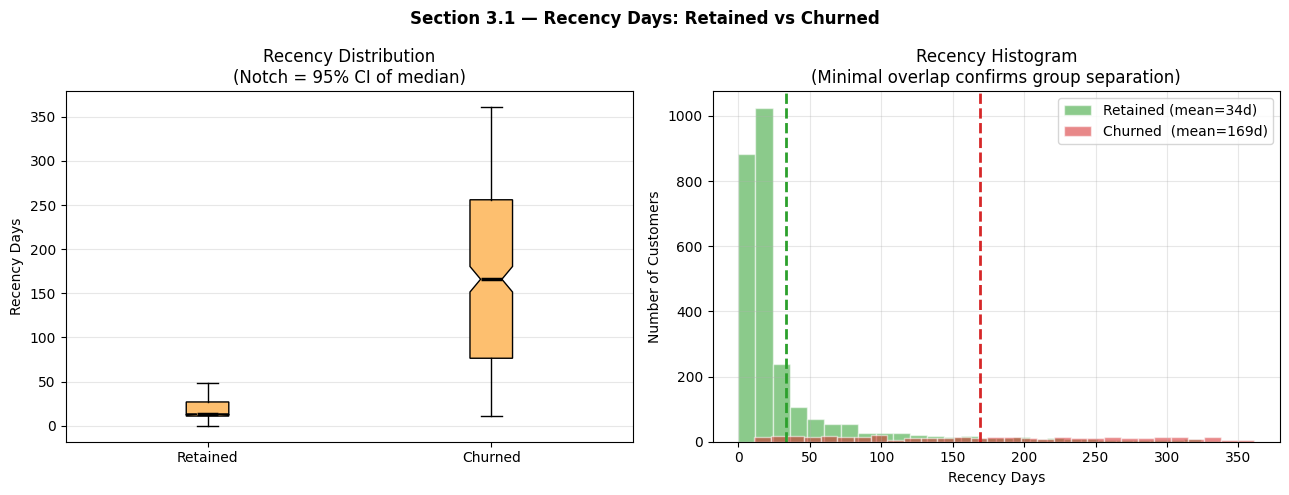


Decision
──────────────────────────────────────────────────
  p-value (4.032e-88) < α (0.05)
  → Reject H₀.
  → Churned customers have significantly higher recency days than retained customers.


In [70]:
# Step 3: Perform the t-test and find the p-value
# Separate the rencency days from retained and churned data
retained = churn_df[churn_df["churned"]==0]
churned  = churn_df[churn_df["churned"]==1]
r = retained["recency_days"].values
c = churned["recency_days"].values

# a. Descriptive statistics
print("Descriptive Statistics")
print("─" * 50)
print(f"  Retained : n={len(r):,}  mean={r.mean():.1f}d  "
      f"median={np.median(r):.0f}d  std={r.std(ddof=1):.1f}d")
print(f"  Churned  : n={len(c):,}  mean={c.mean():.1f}d  "
      f"median={np.median(c):.0f}d  std={c.std(ddof=1):.1f}d")

# b. Levene's test (check variance equality)
lev_stat, lev_p = stats.levene(r, c)
print(f"\nLevene's Test for Equality of Variances")
print("─" * 50)
print(f"  stat = {lev_stat:.3f},  p = {lev_p:.4f}")
if lev_p < 0.05:
    print("  → Variances are significantly unequal (p < 0.05).")
    print("  → Welch's t-test (equal_var=False) applied.")
else:
    print("  → No significant difference in variances (p ≥ 0.05).")

# c. Welch's t-test (upper-tailed)
t_stat, p_val = stats.ttest_ind(c, r, equal_var=False, alternative='greater')
diff = c.mean()-r.mean()

print(f"\nWelch's t-test Results  (Hₐ: μ_churned > μ_retained)")
print("─" * 50)
print(f"  t-statistic     = {t_stat:.3f}")
print(f"  p-value         = {p_val:.3e}  (one-tailed)")
print(f"  Mean difference = {diff:.1f} days  (churned − retained)")

# d. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot([r, c], labels=["Retained","Churned"],
                showfliers=False, patch_artist=True, notch=True,
                boxprops=dict(facecolor="#fdbf6f"),
                medianprops=dict(color="black", linewidth=2.5))
axes[0].set_ylabel("Recency Days")
axes[0].set_title("Recency Distribution\n(Notch = 95% CI of median)")
axes[0].grid(axis="y", alpha=0.3)
axes[1].hist(r, bins=30, alpha=0.55, color="#2ca02c",
             label=f"Retained (mean={r.mean():.0f}d)", edgecolor="white")
axes[1].hist(c, bins=30, alpha=0.55, color="#d62728",
             label=f"Churned  (mean={c.mean():.0f}d)", edgecolor="white")
axes[1].axvline(r.mean(), color="#2ca02c", linestyle="--", lw=2)
axes[1].axvline(c.mean(), color="#d62728", linestyle="--", lw=2)
axes[1].set_xlabel("Recency Days")
axes[1].set_ylabel("Number of Customers")
axes[1].set_title("Recency Histogram\n(Minimal overlap confirms group separation)")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle("Section 3.1 — Recency Days: Retained vs Churned",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

# e. Decision and Interpretation
alpha = 0.05
print("\nDecision")
print("─" * 50)
if p_val < alpha:
    print(f"  p-value ({p_val:.3e}) < α ({alpha})")
    print("  → Reject H₀.")
    print("  → Churned customers have significantly higher recency days than retained customers.")
else:
    print(f"  p-value ({p_val:.3e}) ≥ α ({alpha})")
    print("  → Fail to reject H₀.")
    print("  → No sufficient evidence that churned customers stopped buying earlier.")

**INSIGHT:** <br>
There is overwhelming statistical evidence to reject the null hypothesis (t-statistic significant at p = 4.032e-88, well below α = 0.05). On average, churned customers made their last purchase 169.2 days before year-end compared to just 33.7 days for retained customers, a gap of more than 135 days. The median values reinforce this further, with churned customers last purchasing 166 days before year-end while retained customers were still active just 13 days prior. Levene's test confirmed significantly unequal variances between the two groups, justifying the use of Welch's separate-variance t-test over the pooled Student's t-test. The minimal overlap in the recency histogram confirms that this difference is not a statistical artefact but a genuine structural separation between the two groups.

**VALUE TO MANAGEMENT:** <br>
LuminaTech would benefit from implementing an automated inactivity alert system that flags any previously active account that has not placed an order within 83 days. Sales representatives should be prompted to contact flagged accounts within five business days of the alert being triggered. This approach would allow LuminaTech to intervene before a customer fully disengages, turning a reactive process into a proactive one. Given that 86.3% of customers who crossed this threshold did not return, early outreach could meaningfully reduce the number of accounts lost each year.

### 3.2 Test whether churned customers purchased across significantly fewer months than retained customers.

*   **Data source**: churn_df
*   **Objective**: To determine whether churned customers have a significantly lower number of active months compared to retained customers. In other words, to test whether customers who stopped purchasing had less consistent buying behaviour across the observation period, which would confirm that months active is a meaningful indicator of customer churn for LuminaTech Lighting's management team.

#### **Two-sample lower-tailed t-test**

**Step 1: State the Null Hypothesis and the Alternative Hypothesis**

*Null Hypothesis (H₀):* Churned customers do not have fewer active months than retained customers (μ_churned ≥ μ_retained).

*Alternative Hypothesis (Hₐ):* Churned customers have significantly fewer active months than retained customers (μ_churned < μ_retained).

**Step 2: Choose a Significance Level**

A significance level of α = 0.05 (5%) is applied.

Descriptive Statistics
──────────────────────────────────────────────────
  Retained : n=2,691  mean=9.57 months  median=12  std=3.62
  Churned  : n=379  mean=2.86 months  median=2  std=2.65

Levene's Test for Equality of Variances
──────────────────────────────────────────────────
  stat = 12.708,  p = 0.0004
  → Variances are significantly unequal (p < 0.05).
  → Welch's t-test (equal_var=False) applied.

Welch's t-test Results  (Hₐ: μ_churned < μ_retained)
──────────────────────────────────────────────────
  t-statistic     = -43.847
  p-value         = 4.574e-189  (one-tailed)
  Mean difference = 6.70 months  (retained − churned)


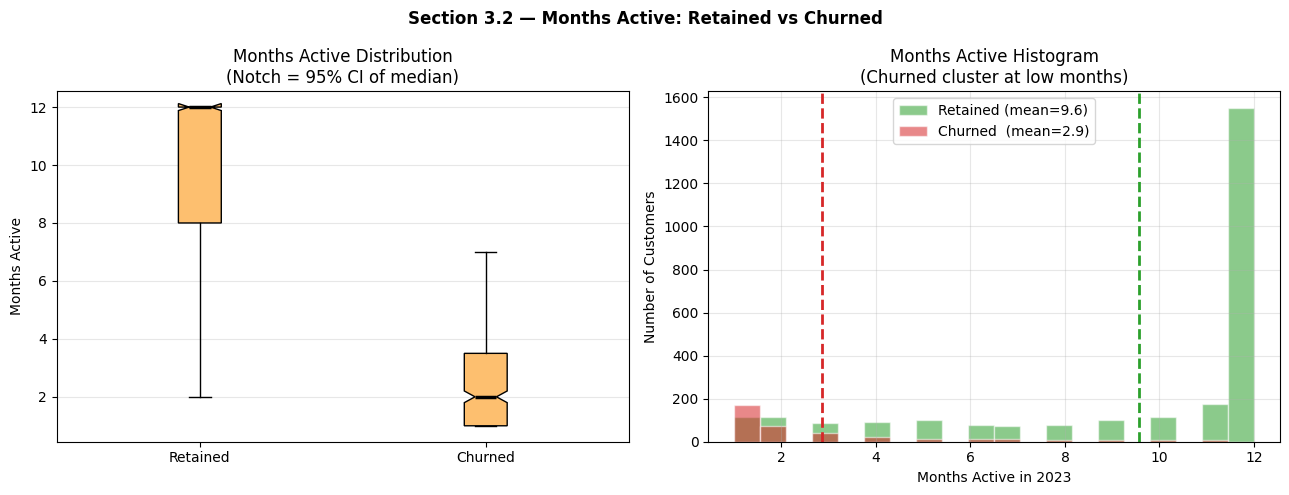


Decision
──────────────────────────────────────────────────
  p-value (4.574e-189) < α (0.05)
  → Reject H₀.
  → Churned customers have significantly fewer active months than retained customers.


In [71]:
# Step 3: Perform the t-test and Find the p-value
# Separate the months active from retained and churned data
retained = churn_df[churn_df["churned"]==0]
churned  = churn_df[churn_df["churned"]==1]
r = retained["n_months_active"].values
c = churned["n_months_active"].values

# a. Descriptive statistics
print("Descriptive Statistics")
print("─" * 50)
print(f"  Retained : n={len(r):,}  mean={r.mean():.2f} months  "
      f"median={np.median(r):.0f}  std={r.std(ddof=1):.2f}")
print(f"  Churned  : n={len(c):,}  mean={c.mean():.2f} months  "
      f"median={np.median(c):.0f}  std={c.std(ddof=1):.2f}")

# b. Levene's test (check variance equality)
lev_stat, lev_p = stats.levene(r, c)
print(f"\nLevene's Test for Equality of Variances")
print("─" * 50)
print(f"  stat = {lev_stat:.3f},  p = {lev_p:.4f}")
if lev_p < 0.05:
    print("  → Variances are significantly unequal (p < 0.05).")
    print("  → Welch's t-test (equal_var=False) applied.")
else:
    print("  → No significant difference in variances (p ≥ 0.05).")

# c. Welch's t-test (lower-tailed)
t_stat, p_val = stats.ttest_ind(c, r, equal_var=False, alternative='less')
diff = r.mean() - c.mean()

print(f"\nWelch's t-test Results  (Hₐ: μ_churned < μ_retained)")
print("─" * 50)
print(f"  t-statistic     = {t_stat:.3f}")
print(f"  p-value         = {p_val:.3e}  (one-tailed)")
print(f"  Mean difference = {diff:.2f} months  (retained − churned)")

# d. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot([r, c], labels=["Retained","Churned"],
                showfliers=False, patch_artist=True, notch=True,
                boxprops=dict(facecolor="#fdbf6f"),
                medianprops=dict(color="black", linewidth=2.5))
axes[0].set_ylabel("Months Active")
axes[0].set_title("Months Active Distribution\n(Notch = 95% CI of median)")
axes[0].grid(axis="y", alpha=0.3)
axes[1].hist(r, bins=20, alpha=0.55, color="#2ca02c",
             label=f"Retained (mean={r.mean():.1f})", edgecolor="white")
axes[1].hist(c, bins=20, alpha=0.55, color="#d62728",
             label=f"Churned  (mean={c.mean():.1f})", edgecolor="white")
axes[1].axvline(r.mean(), color="#2ca02c", linestyle="--", lw=2)
axes[1].axvline(c.mean(), color="#d62728", linestyle="--", lw=2)
axes[1].set_xlabel("Months Active in 2023")
axes[1].set_ylabel("Number of Customers")
axes[1].set_title("Months Active Histogram\n(Churned cluster at low months)")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle("Section 3.2 — Months Active: Retained vs Churned",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

# e. Decision and Interpretation
alpha = 0.05
print("\nDecision")
print("─" * 50)
if p_val < alpha:
    print(f"  p-value ({p_val:.3e}) < α ({alpha})")
    print("  → Reject H₀.")
    print("  → Churned customers have significantly fewer active months than retained customers.")
else:
    print(f"  p-value ({p_val:.3e}) ≥ α ({alpha})")
    print("  → Fail to reject H₀.")
    print("  → No sufficient evidence that churned customers purchased across fewer months.")

**INSIGHT:** <br>
There is sufficient statistical evidence to reject the null hypothesis (p = 4.574e-189, well below α = 0.05). Retained customers were active across a mean of 9.57 distinct months compared to just 2.86 months for churned customers, a difference of nearly 7 months. The median values tell an even starker story, with retained customers purchasing in a median of 12 months (effectively the full year) while churned customers were active in just 2 months. This confirms that churned customers are overwhelmingly burst-and-exit buyers who never formed a recurring purchasing habit, while retained customers distributed their orders consistently across the full observation period. The extremely low p-value reflects just how structurally different these two groups are in terms of purchase consistency.

**VALUE TO MANAGEMENT:** <br>
LuminaTech would benefit from prioritising early repeat purchase campaigns targeting new accounts in their first 60 days. A customer who places a second or third order within that window is significantly more likely to develop a recurring buying habit. LuminaTech could implement follow-up outreach after a customer's first order, paired with tailored product recommendations or loyalty incentives, to encourage a return visit before the initial engagement fades. Building purchasing consistency early in the customer lifecycle is likely to be one of the most cost-effective retention strategies available to the business.

### 3.3 Test whether customers who churned had a significantly different average transaction value compared to those who were retained

*  **Data source:** churn_df
*  **Objective:** To determine whether churned customers have a significantly different average transaction value compared to retained customers. In other words, to test whether the size of a customer's transactions is a meaningful differentiator between churned and retained customers, which would inform whether transaction value should be considered as an indicator of churn risk for LuminaTech Lighting's management team.

#### **Two-sample two-tailed t-test**

**Step 1: State the Null Hypothesis and the Alternative Hypothesis**

*Null Hypothesis (H₀):* There is no significant difference in average transaction value between churned and retained customers (μ_churned = μ_retained).

*Alternative Hypothesis (Hₐ):* There is a significant difference in average transaction value between churned and retained customers (μ_churned ≠ μ_retained).

A two-tailed test is applied as no directional expectation was formed in advance — the difference in average transaction value could exist in either direction.

**Step 2: Choose a Significance Level**

A significance level of α = 0.05 (5%) is applied.

Descriptive Statistics
──────────────────────────────────────────────────
  Retained : n=2,691  mean=$95  median=$96  std=$45
  Churned  : n=379  mean=$106  median=$77  std=$76

Levene's Test for Equality of Variances
──────────────────────────────────────────────────
  stat = 104.947,  p = 0.0000
  → Variances are significantly unequal (p < 0.05).
  → Welch's t-test (equal_var=False) applied.

Welch's t-test Results  (Hₐ: μ_churned ≠ μ_retained)
──────────────────────────────────────────────────
  t-statistic     = 2.834
  p-value         = 4.818e-03  (two-tailed)
  Mean difference = $11  (churned − retained)


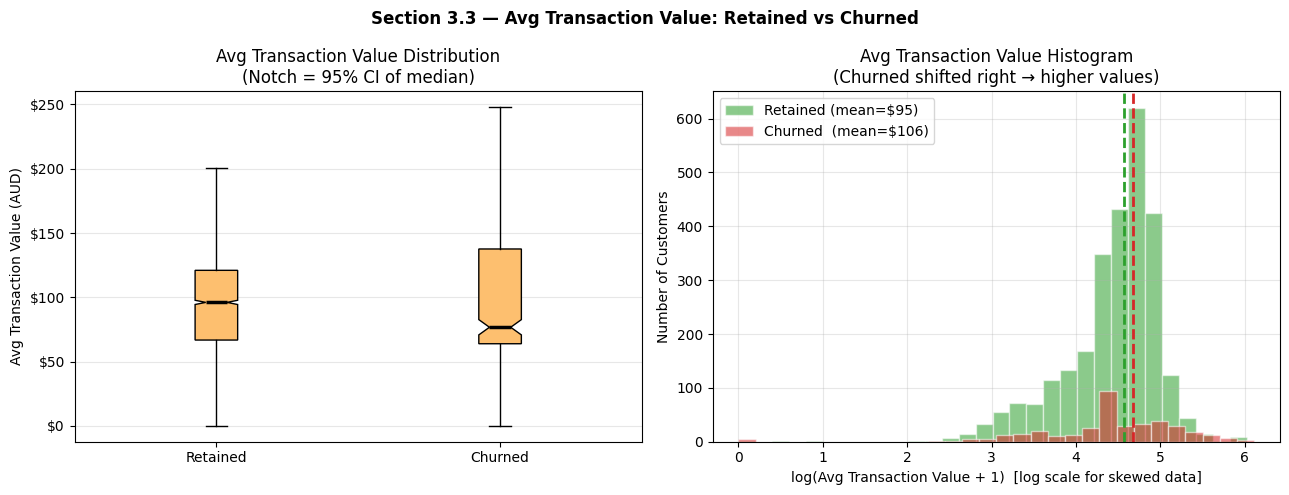


Decision
──────────────────────────────────────────────────
  p-value (4.818e-03) < α (0.05)
  → Reject H₀.
  → There is a significant difference in average transaction value between the two groups.


In [72]:
# Step 3: Perform the t-test and Find the p-value
# Separate the average transaction value from retained and churned data
retained = churn_df[churn_df["churned"]==0]
churned  = churn_df[churn_df["churned"]==1]
r = retained["avg_txn_value"].values
c = churned["avg_txn_value"].values

# a. Descriptive statistics
print("Descriptive Statistics")
print("─" * 50)
print(f"  Retained : n={len(r):,}  mean=${r.mean():,.0f}  "
      f"median=${np.median(r):,.0f}  std=${r.std(ddof=1):,.0f}")
print(f"  Churned  : n={len(c):,}  mean=${c.mean():,.0f}  "
      f"median=${np.median(c):,.0f}  std=${c.std(ddof=1):,.0f}")

# b. Levene's test (check variance equality)
lev_stat, lev_p = stats.levene(r, c)
print(f"\nLevene's Test for Equality of Variances")
print("─" * 50)
print(f"  stat = {lev_stat:.3f},  p = {lev_p:.4f}")
if lev_p < 0.05:
    print("  → Variances are significantly unequal (p < 0.05).")
    print("  → Welch's t-test (equal_var=False) applied.")
else:
    print("  → No significant difference in variances (p ≥ 0.05).")

# c. Welch's t-test (two-tailed)
# Two-tailed test used as no directional expectation was formed in advance.
t_stat, p_val = stats.ttest_ind(c, r, equal_var=False)
diff = c.mean() - r.mean()

print(f"\nWelch's t-test Results  (Hₐ: μ_churned ≠ μ_retained)")
print("─" * 50)
print(f"  t-statistic     = {t_stat:.3f}")
print(f"  p-value         = {p_val:.3e}  (two-tailed)")
print(f"  Mean difference = ${diff:,.0f}  (churned − retained)")

# d. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot([r, c], labels=["Retained","Churned"],
                showfliers=False, patch_artist=True, notch=True,
                boxprops=dict(facecolor="#fdbf6f"),
                medianprops=dict(color="black", linewidth=2.5))
axes[0].set_ylabel("Avg Transaction Value (AUD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].set_title("Avg Transaction Value Distribution\n(Notch = 95% CI of median)")
axes[0].grid(axis="y", alpha=0.3)
axes[1].hist(np.log1p(r), bins=30, alpha=0.55, color="#2ca02c",
             label=f"Retained (mean=${r.mean():,.0f})", edgecolor="white")
axes[1].hist(np.log1p(c), bins=30, alpha=0.55, color="#d62728",
             label=f"Churned  (mean=${c.mean():,.0f})", edgecolor="white")
axes[1].axvline(np.log1p(r.mean()), color="#2ca02c", linestyle="--", lw=2)
axes[1].axvline(np.log1p(c.mean()), color="#d62728", linestyle="--", lw=2)
axes[1].set_xlabel("log(Avg Transaction Value + 1)  [log scale for skewed data]")
axes[1].set_ylabel("Number of Customers")
axes[1].set_title("Avg Transaction Value Histogram\n(Churned shifted right → higher values)")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle("Section 3.3 — Avg Transaction Value: Retained vs Churned",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

# e. Decision and Interpretation
alpha = 0.05
print("\nDecision")
print("─" * 50)
if p_val < alpha:
    print(f"  p-value ({p_val:.3e}) < α ({alpha})")
    print("  → Reject H₀.")
    print("  → There is a significant difference in average transaction value between the two groups.")
else:
    print(f"  p-value ({p_val:.3e}) ≥ α ({alpha})")
    print("  → Fail to reject H₀.")
    print("  → No sufficient evidence of a significant difference in average transaction value.")

**INSIGHT:** <br>
There is sufficient statistical evidence to reject the null hypothesis (p = 4.818e-03, below α = 0.05). Churned customers had a higher average transaction value ($106) compared to retained customers ($95), which is a counterintuitive finding. This result reveals that churned customers are not low-value buyers who are easily replaced. They are project-driven accounts who place fewer but larger orders concentrated within a short burst of activity before exiting entirely. This interpretation is fully consistent with the Section 3.2 finding that churned customers were active in a median of just 2 months. The higher per-order spend masks the fact that total lifetime value is far lower due to the absence of any recurring purchasing habit.

**VALUE TO MANAGEMENT:** <br>
LuminaTech would benefit from shifting its retention strategy away from account value as a primary risk filter. A high-spend account with low order frequency and high recency days is at significantly elevated churn risk, regardless of how much that customer has previously spent. LuminaTech's sales teams should be trained to proactively engage large, infrequent accounts during an active project to understand upcoming needs and identify the next opportunity before the current engagement concludes. Converting a project buyer into a habitual account would deliver far greater long-term revenue than any single large transaction.

### Section 4: Prediction (in this section, add as many cells as you need)
Developed a predictive model to forecast a meaningful outcome variable based on the dataset and business context. Evaluated model performance using appropriate metrics and interpreted key factors influencing predictions.



## Churn Prediction Model

### What We Are Predicting

**Research question:** Which behavioural features, including recency, transaction
frequency, engagement consistency, spend, profitability, and geographic district, best predict whether a LuminaTech customer will churn, and how accurately can the
model identify at-risk customers before they leave?

**Dependent variable (y):** churned — binary outcome (1 = did not return in 2024,
0 = returned in 2024).

**Independent variables (x):**
- **Numerical:** total_spend, total_profit, avg_txn_value, avg_margin, n_transactions, n_months_active, total_quantity, n_business_areas, n_distinct_items, n_distinct_salesppl, recency_days, tenure_days
- **Categorical:** district_name

### Model Evaluation Criteria

Both models (Logistic Regression and Random Forest) are evaluated using the
following metrics at **significance level $\alpha = 0.05$**:

| Metric | Purpose |
|---|---|
| **Recall** | Primary — proportion of actual churners correctly identified |
| **ROC-AUC** | Overall discriminatory power across all decision thresholds |
| **Precision** | Proportion of predicted churners who actually churned |
| **F1 Score** | Harmonic balance between precision and recall |
| **Accuracy** | Overall correct predictions (interpreted with caution due to class imbalance) |

Recall is treated as the most important metric because **missing a churner
(false negative) has a higher business cost** than a false alarm. A customer
who leaves without intervention represents permanently lost revenue, whereas a
false alarm merely results in an unnecessary but low-cost retention contact.

## 4.1 Data Manipulation

### 4.1.1 One Hot Encoding
One-hot encoding was applied to **district_name** as it is a strict requirement for Logistic Regression, which cannot interpret categorical labels mathematically. Random Forest by nature does not require one-hot encoding since tree-based models can split on categorical group membership directly. However, scikit-learn's RandomForestClassifier does not support categorical inputs natively, so numerical encoding is required for technical compatibility.

In [73]:
# Perform one-hot encoding, dropping the first category to avoid the dummy variable trap
churn_df = pd.get_dummies(churn_df, columns= ['district_name'], drop_first=True)

# Convert any boolean columns to integers (in case False/True values appear instead of 0/1)
bool_cols = churn_df.select_dtypes(include='bool').columns
churn_df[bool_cols] = churn_df[bool_cols].astype(int)

### 4.1.2 Define Dependent and Independent Variables

In [74]:
# Use modelling_features from section 1.15
x = churn_df.drop(['customer_code','churned','last_purchase'],axis=1)
y = churn_df['churned']

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

x shape: (3070, 22)
y shape: (3070,)


## 4.2 Logistic Regression
Logistic Regression was selected because the target variable churned is binary (0 = retained, 1 = churned), which is exactly what logistic regression is designed for. Unlike linear regression, it constrains predictions to a probability between 0 and 1, making the output directly interpretable as a churn likelihood score. It is also transparent, where each coefficient explains how a feature increases or decreases churn probability, which makes the findings actionable for management. The model uses class_weight='balanced' to handle the 87.7%/12.3% class imbalance without requiring resampling.

### 4.2.1 Check Model Assumption: Multicollinearity (VIF)

In [75]:
# Assumption 1: No Multicollinearity
# Calculate VIF for each features
def calc_vif(x):
  vif = pd.DataFrame()
  vif['Variables'] = x.columns
  vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

  return vif

vif = calc_vif(x)
vif.style.highlight_max(color = "red", subset=["VIF"])

,Variables,VIF
0,total_spend,889.802371
1,total_profit,920.779834
2,avg_txn_value,5.980968
3,n_transactions,58.729581
4,n_months_active,47.800136
5,total_quantity,49.985103
6,n_business_areas,18.402103
7,n_distinct_items,22.654891
8,n_distinct_salesppl,12.046980
9,recency_days,2.975180


In [76]:
x_lr = x.drop(['total_profit'], axis = 1)
vif = calc_vif(x_lr)
vif.style.highlight_max(color = "red", subset=["VIF"])

,Variables,VIF
0,total_spend,29.874855
1,avg_txn_value,5.979958
2,n_transactions,56.188741
3,n_months_active,47.791133
4,total_quantity,49.023325
5,n_business_areas,18.380908
6,n_distinct_items,22.395294
7,n_distinct_salesppl,11.991397
8,recency_days,2.975151
9,tenure_days,46.036219


In [77]:
x_lr = x_lr.drop(['n_transactions'], axis = 1)
vif = calc_vif(x_lr)
vif.style.highlight_max(color = "red", subset=["VIF"])

,Variables,VIF
0,total_spend,24.108538
1,avg_txn_value,5.897090
2,n_months_active,47.466139
3,total_quantity,29.266993
4,n_business_areas,18.379352
5,n_distinct_items,21.931644
6,n_distinct_salesppl,11.389986
7,recency_days,2.969001
8,tenure_days,46.031454
9,avg_margin,1.715093


In [78]:
x_lr = x_lr.drop(['n_months_active'], axis = 1)
vif = calc_vif(x_lr)
vif.style.highlight_max(color = "red", subset=["VIF"])

,Variables,VIF
0,total_spend,23.775100
1,avg_txn_value,5.880388
2,total_quantity,28.731639
3,n_business_areas,15.969888
4,n_distinct_items,21.885724
5,n_distinct_salesppl,11.383863
6,recency_days,2.968970
7,tenure_days,16.655914
8,avg_margin,1.714994
9,district_name_Adelaide,2.380615


In [79]:
x_lr = x_lr.drop(['total_quantity'], axis = 1)
vif = calc_vif(x_lr)
vif.style.highlight_max(color = "red", subset=["VIF"])

,Variables,VIF
0,total_spend,9.076500
1,avg_txn_value,5.712569
2,n_business_areas,14.442426
3,n_distinct_items,17.815808
4,n_distinct_salesppl,11.309715
5,recency_days,2.956321
6,tenure_days,15.947251
7,avg_margin,1.712152
8,district_name_Adelaide,2.363503
9,district_name_Brisbane,3.759302


In [80]:
x_lr = x_lr.drop(['n_distinct_items'], axis = 1)
vif = calc_vif(x_lr)
vif.style.highlight_max(color = "red", subset=["VIF"])

,Variables,VIF
0,total_spend,1.387250
1,avg_txn_value,5.289127
2,n_business_areas,9.331962
3,n_distinct_salesppl,11.153831
4,recency_days,2.955763
5,tenure_days,15.894698
6,avg_margin,1.711502
7,district_name_Adelaide,2.363482
8,district_name_Brisbane,3.757047
9,district_name_Darwin,1.165237


In [81]:
x_lr = x_lr.drop(['tenure_days'], axis = 1)
vif = calc_vif(x_lr)
vif.style.highlight_max(color = "red", subset=["VIF"])

,Variables,VIF
0,total_spend,1.382023
1,avg_txn_value,5.288978
2,n_business_areas,7.919109
3,n_distinct_salesppl,10.923919
4,recency_days,1.959505
5,avg_margin,1.703200
6,district_name_Adelaide,1.681538
7,district_name_Brisbane,2.339896
8,district_name_Darwin,1.093008
9,district_name_Head Office Sales,1.235293


In [82]:
x_lr = x_lr.drop(['n_distinct_salesppl'], axis = 1)
vif = calc_vif(x_lr)
vif

,Variables,VIF
0,total_spend,1.378991
1,avg_txn_value,4.703988
2,n_business_areas,4.863775
3,recency_days,1.958408
4,avg_margin,1.703097
5,district_name_Adelaide,1.622323
6,district_name_Brisbane,2.200567
7,district_name_Darwin,1.081478
8,district_name_Head Office Sales,1.230052
9,district_name_Intercompany Sales,1.138803


After sequentially removing **total_profit**, **n_transactions**, **n_months_active**, **total_quantity**, **n_distinct_items**, **tenure_days**, and **n_distinct_salesppl**, all remaining features show VIF values below 5.0, the accepted threshold for acceptable multicollinearity. All one-hot encoded district columns show VIF values below 3.0, indicating no problematic correlation between geographic groups.
The final feature set of 15 variables (5 numeric + 10 district dummies) is free from multicollinearity and ready for Logistic Regression training. The dropped features are not lost from the analysis. Their predictive information is largely captured by the retained correlated features, and their importance is independently assessed through the Random Forest feature importances in Section 4.2.

### 4.2.2 Train Test Split Data

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x_lr, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify = y # preserves class ratio in both splits
                                                    )

print(f"\nTraining set: {len(x_train)} samples")
print(f"Test set: {len(x_test)} samples")


Training set: 2149 samples
Test set: 921 samples


### 4.2.3 Data Modelling

In [84]:
# Train logistic regression
lr_model = LogisticRegression(random_state=42, max_iter=20000, class_weight='balanced')
lr_model.fit(x_train, y_train)

print("\nModel trained successfully")

# Make predictions
y_pred = lr_model.predict(x_test)
y_pred_proba = lr_model.predict_proba(x_test)[:, 1]

print("Predictions complete")


Model trained successfully
Predictions complete


### 4.2.4 Performance Evaluation

In [85]:
# Evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Performance Metrics:")
print("-" * 50)
print(f"Accuracy: {lr_accuracy:.3f}")
print(f"Precision: {lr_precision:.3f}")
print(f"Recall: {lr_recall:.3f}")
print(f"F1-Score: {lr_f1:.3f}")
print(f"ROC-AUC: {lr_roc_auc:.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

# Confusion matrix
lr_cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(lr_cm)
print(f"\nTrue Negatives: {lr_cm[0,0]}")
print(f"False Positives: {lr_cm[0,1]}")
print(f"False Negatives: {lr_cm[1,0]}")
print(f"True Positives: {lr_cm[1,1]}")

# Feature coefficients
coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nFeature Coefficients:")
print(coef_df)

Logistic Regression Performance Metrics:
--------------------------------------------------
Accuracy: 0.847
Precision: 0.433
Recall: 0.772
F1-Score: 0.555
ROC-AUC: 0.908

Classification Report:
              precision    recall  f1-score   support

    Retained       0.96      0.86      0.91       807
     Churned       0.43      0.77      0.56       114

    accuracy                           0.85       921
   macro avg       0.70      0.81      0.73       921
weighted avg       0.90      0.85      0.86       921


Confusion Matrix:
[[692 115]
 [ 26  88]]

True Negatives: 692
False Positives: 115
False Negatives: 26
True Positives: 88

Feature Coefficients:
                             Feature  Coefficient
13            district_name_Tasmania    -0.876195
9   district_name_Intercompany Sales     0.841918
10           district_name_Melbourne     0.693744
5             district_name_Adelaide     0.557493
7               district_name_Darwin     0.543815
8    district_name_Head Office Sa

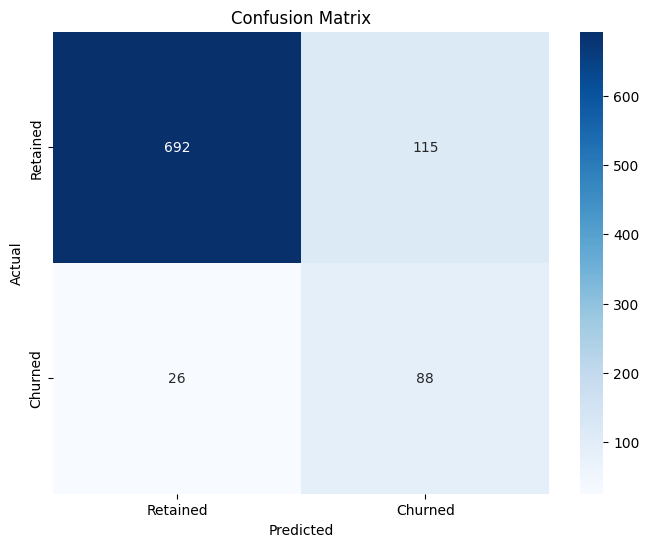

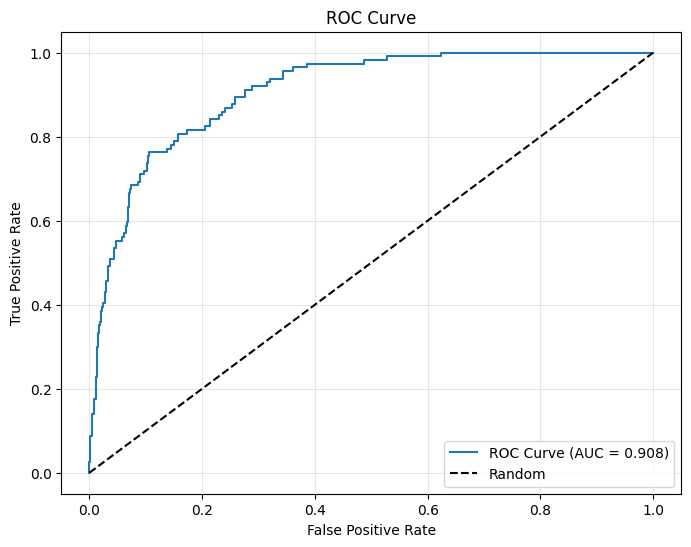

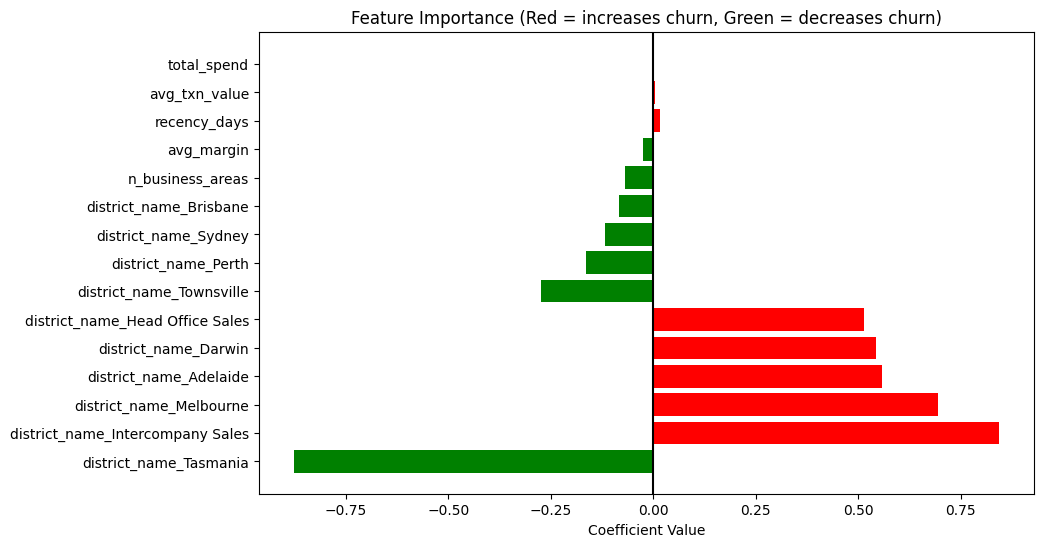

In [86]:
# Confusion Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print(" ")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {lr_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(" ")

# Feature Importance
plt.figure(figsize=(10,6))
colors = ['red' if x > 0 else 'green' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Red = increases churn, Green = decreases churn)')
plt.axvline(x=0, color='black', linestyle='-')
plt.show()

The Logistic Regression model achieves a ROC-AUC of 0.908, indicating excellent overall discriminatory power. The model correctly ranks churned customers above retained customers 90.8% of the time across all possible decision thresholds, confirming that the selected features carry strong predictive signal for churn.

Looking at the most business-critical metric, the model correctly identifies 88 out of 114 actual churners in the test set, giving a recall of 77.2%. This means roughly 3 in every 4 at-risk customers are successfully flagged for intervention before they leave. The 26 false negatives represent churners the model missed entirely. Precision sits at 43.3%, meaning that out of all customers flagged as likely churners, about 43% actually churned and the remaining 115 were false alarms that would result in unnecessary outreach. This tradeoff is an expected and deliberate outcome of using class_weight='balanced', which prioritises catching churners over minimising false alarms. This is the correct business decision since a missed churner carries a higher cost than an unnecessary retention call.

The feature coefficient chart reveals that district-based features appear to dominate visually. This is partly a scaling artefact worth noting. Numeric features like **recency_days** show small raw coefficients because a single unit change represents just one day, while district dummy variables represent the full effect of belonging to a district. A coefficient of 0.016 on **recency_days** actually translates to a substantial cumulative effect across the full 361-day range. Among districts, being classified as Intercompany Sales, Melbourne, and Adelaide meaningfully increases churn probability, while Tasmania and Townsville are associated with significantly lower churn risk, which is consistent with the geographic findings in Section 2.4. Since raw coefficients are not directly comparable across numeric and binary features, the Random Forest model in Section 4.2 provides a more reliable feature importance measure through Gini impurity reduction.

### 4.2.5 Check Assumptions

ASSUMPTION 2: LINEARITY OF THE LOGIT


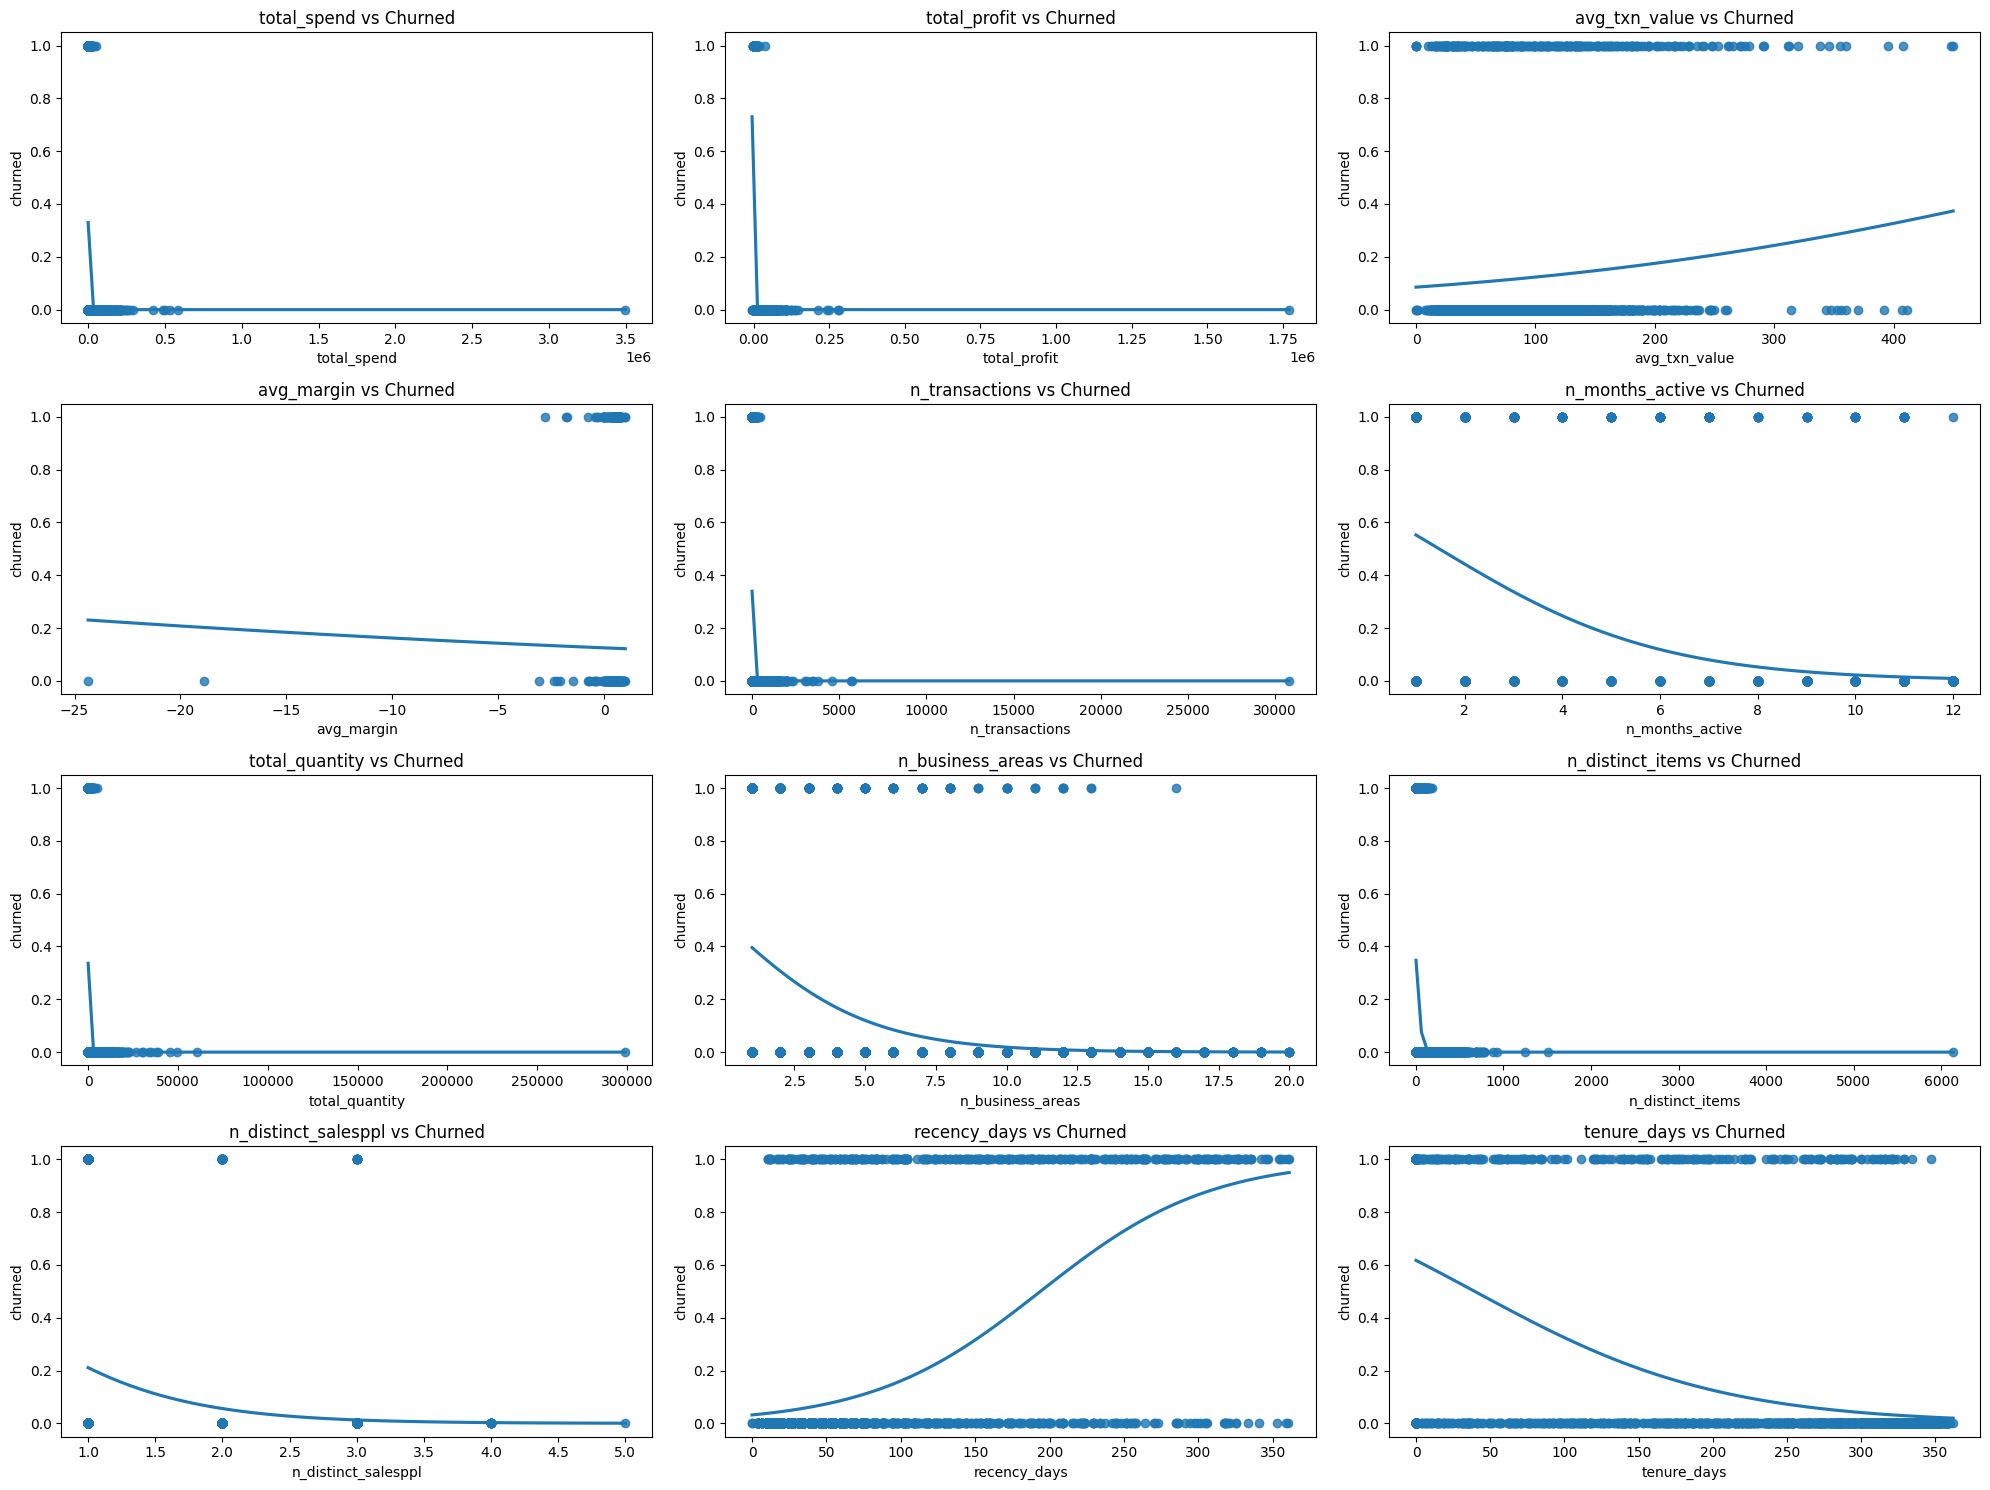

In [87]:
# Assumption 2: Linearity of the Logit

print("ASSUMPTION 2: LINEARITY OF THE LOGIT")

continuous_features = ['total_spend', 'total_profit', 'avg_txn_value', 'avg_margin',
                       'n_transactions', 'n_months_active', 'total_quantity',
                       'n_business_areas', 'n_distinct_items', 'n_distinct_salesppl',
                       'recency_days', 'tenure_days']

plt.figure(figsize=(20, 15))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(4, 3, i)
    sns.regplot(x=churn_df[col], y=churn_df['churned'], logistic=True, ci=None)
    plt.title(f'{col} vs Churned')
plt.tight_layout()
plt.show()

The logistic regression plots show that most features satisfy this assumption to an acceptable degree. The two strongest performers are **recency_days** and **tenure_days**, both showing clear, smooth sigmoid curves that confirm a monotonic and approximately linear relationship with the log-odds of churn. Features such as **n_months_active**, **n_transactions**, and **n_business_areas** also display consistent downward sigmoid patterns, confirming that higher engagement is associated with progressively lower churn probability in a well-behaved way. Features such as **total_spend**, **total_profit**, **total_quantity**, and **n_distinct_items** show relatively flat lines with data heavily concentrated near zero. This is not a true violation of the assumption but rather a visual artefact caused by the highly right-skewed distributions of these features, where most customers cluster at low values with a few extreme cases far to the right. The assumption is considered sufficiently satisfied for model training to proceed.

ASSUMPTION 3: NO EXTREME OUTLIERS
                Feature  Outliers_Count  Outliers_Percentage
0           total_spend              10                 0.33
1          total_profit               9                 0.29
2         avg_txn_value              40                 1.30
3            avg_margin              10                 0.33
4        n_transactions              10                 0.33
5       n_months_active               0                 0.00
6        total_quantity              12                 0.39
7      n_business_areas               0                 0.00
8      n_distinct_items              22                 0.72
9   n_distinct_salesppl               1                 0.03
10         recency_days             103                 3.36
11          tenure_days               0                 0.00

Interpretation:
Using Z-score > 3 as threshold for extreme outliers.
High outlier percentages may affect model performance.


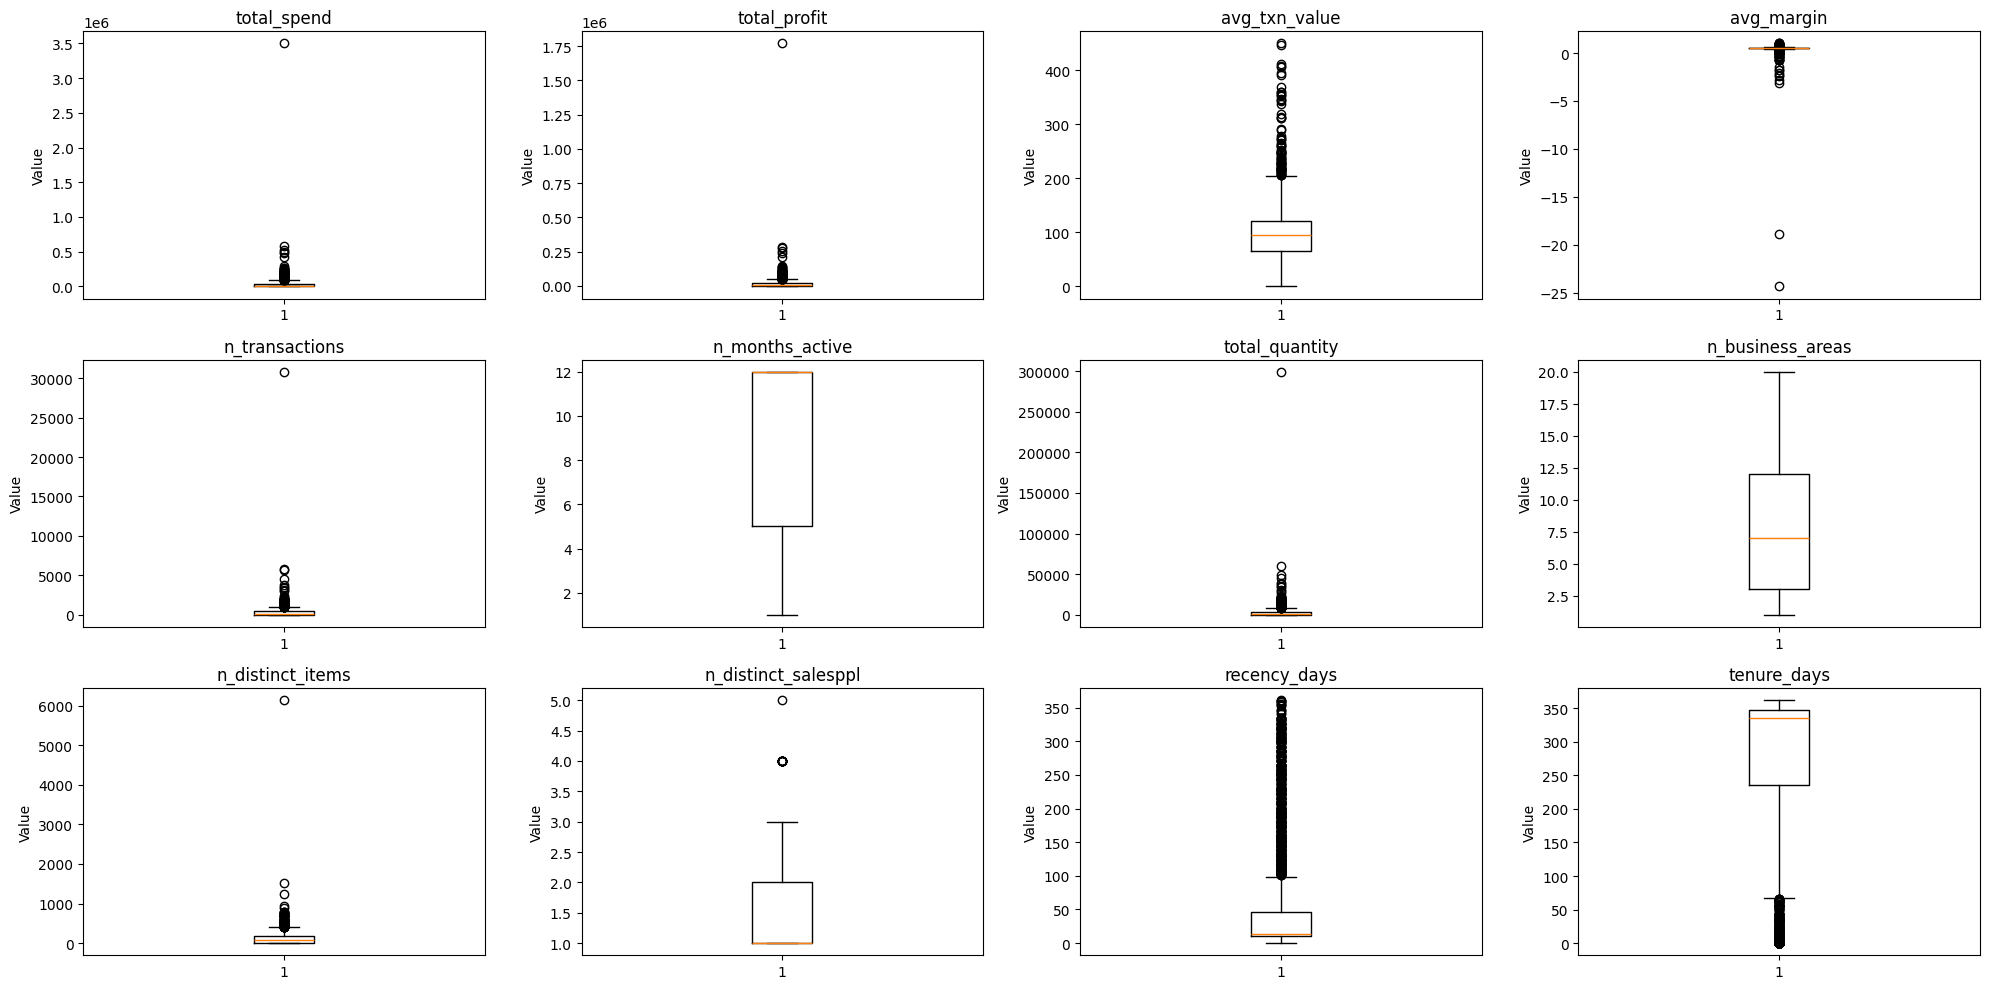


All assumption checks complete.


In [88]:
# Assumption 3: No Extreme Outliers

print("ASSUMPTION 3: NO EXTREME OUTLIERS")

# from scipy import stats

continuous_features = ['total_spend', 'total_profit', 'avg_txn_value', 'avg_margin',
                       'n_transactions', 'n_months_active', 'total_quantity',
                       'n_business_areas', 'n_distinct_items', 'n_distinct_salesppl',
                       'recency_days', 'tenure_days']

# Check for outliers using Z-score
z_scores = np.abs(stats.zscore(churn_df[continuous_features].fillna(0)))
outliers = (z_scores > 3).sum(axis=0)

outlier_df = pd.DataFrame({
    'Feature': continuous_features,
    'Outliers_Count': outliers,
    'Outliers_Percentage': (outliers / len(churn_df) * 100).round(2)
})

print(outlier_df)

print("\nInterpretation:")
print("Using Z-score > 3 as threshold for extreme outliers.")
print("High outlier percentages may affect model performance.")

# Visualize outliers with boxplots
plt.figure(figsize=(20, 10))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(3, 4, i)
    plt.boxplot(churn_df[col].dropna())
    plt.title(col)
    plt.ylabel('Value')
plt.tight_layout()
plt.show()

print("\nAll assumption checks complete.")

All features show very low outlier percentages based on the Z-score threshold of 3. The majority of features have fewer than 1% of observations flagged, and **avg_margin**, **n_months_active**, **n_business_areas**, and **tenure_days** have zero extreme outliers entirely. The highest proportion belongs to **recency_days** at 3.36% with 103 flagged observations. This is not a data quality concern but rather a reflection of genuine customer behaviour. Some customers genuinely stopped transacting very early in 2023 and therefore have legitimately high recency values. Since outlier imputation was already applied to the transaction-level data in Section 1.12, these residual extreme values at the customer level represent real behavioural patterns that the model should be allowed to learn from rather than suppress. The assumption is satisfied and no further treatment is required before modelling.

## 4.3 Random Forest
Random Forest was selected as the second model to complement Logistic Regression. While Logistic Regression assumes a linear relationship between features and the log-odds of churn, Random Forest is a non-parametric ensemble method that captures non-linear relationships and feature interactions automatically without requiring any distributional assumptions. It also provides scale-invariant feature importances through Gini impurity reduction, which gives a more reliable ranking of feature contributions than raw logistic regression coefficients. It is particularly useful given the mixed numeric and binary features in this dataset. The two models together offer a complete picture. Logistic Regression provides interpretable, coefficient-based insights, while Random Forest validates those findings from a purely predictive standpoint.

### 4.3.1 Train Test Split Data

In [89]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify = y # preserves class ratio in both splits
                                                    )

print(f"\nTraining set: {len(x_train)} samples")
print(f"Test set: {len(x_test)} samples")


Training set: 2149 samples
Test set: 921 samples


### 4.3.2 Data Modelling

In [90]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators  = 100, # number of trees
    class_weight  = "balanced", # account for class imbalance (13% churned)
    random_state  = 42,
    n_jobs        = -1 # use all CPU cores
)
rf_model.fit(x_train, y_train)

# Make Predictions
rf_pred   = rf_model.predict(x_test)
rf_proba = rf_model.predict_proba(x_test)[:, 1] # probability of churn class

### 4.3.3 Performance Evaluation

In [91]:
# Evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print("Random Forest — Performance Metrics")
print("-" * 50)
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Retained', 'Churned']))

# Confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)
print("\nConfusion Matrix:")
print(rf_cm)
print(f"\nTrue Negatives: {rf_cm[0,0]}")
print(f"False Positives: {rf_cm[0,1]}")
print(f"False Negatives: {rf_cm[1,0]}")
print(f"True Positives: {rf_cm[1,1]}")

Random Forest — Performance Metrics
--------------------------------------------------
Accuracy  : 0.8990
Precision : 0.6615
Recall    : 0.3772
F1 Score  : 0.4804
ROC-AUC   : 0.9351

Classification Report:
              precision    recall  f1-score   support

    Retained       0.92      0.97      0.94       807
     Churned       0.66      0.38      0.48       114

    accuracy                           0.90       921
   macro avg       0.79      0.67      0.71       921
weighted avg       0.89      0.90      0.89       921


Confusion Matrix:
[[785  22]
 [ 71  43]]

True Negatives: 785
False Positives: 22
False Negatives: 71
True Positives: 43


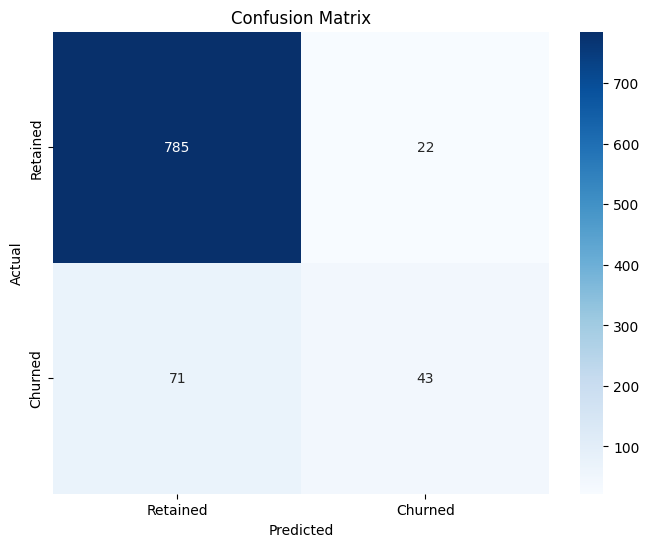

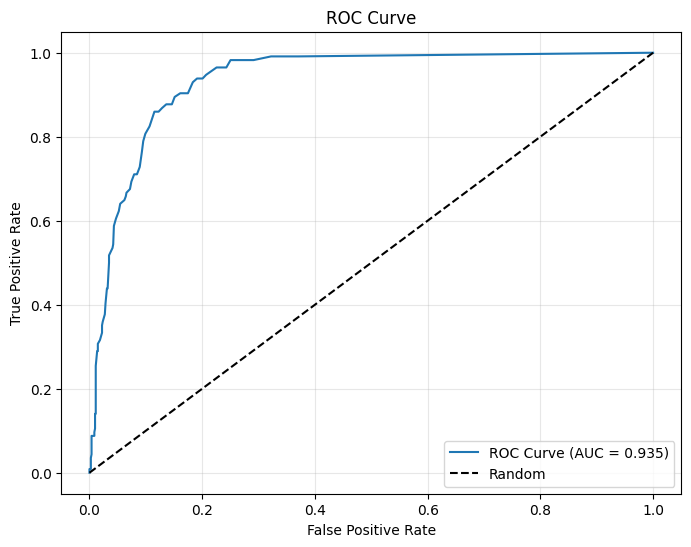

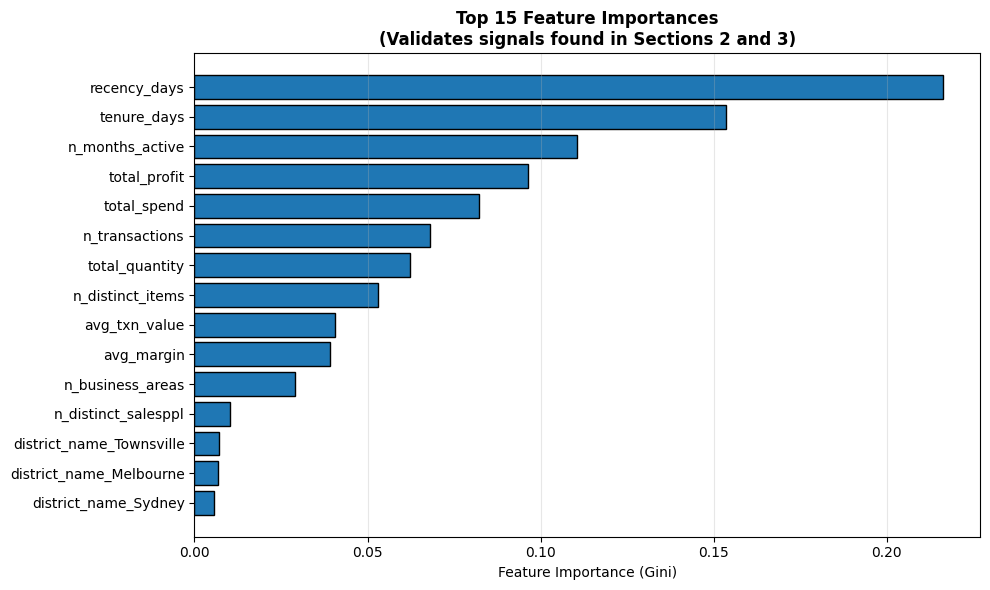

In [92]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print(" ")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {rf_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(" ")

# Feature Importance
feat_names = x_train.columns.tolist()
importance  = rf_model.feature_importances_
imp_df      = (pd.DataFrame({"Feature": feat_names, "Importance": importance})
               .sort_values("Importance", ascending=False)
               .head(15))

plt.figure(figsize=(10, 6))
plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1],
         color="#1f77b4", edgecolor="black")
plt.xlabel("Feature Importance (Gini)")
plt.title("Top 15 Feature Importances\n"
          "(Validates signals found in Sections 2 and 3)",
          fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

The Random Forest model achieves a ROC-AUC of 0.935, which is higher than Logistic Regression (0.908), confirming it has superior overall discriminatory power when evaluated across all decision thresholds. The confusion matrix shows that the model correctly identifies 785 retained and 43 churned customers, while misclassifying 22 retained customers as churned and missing 71 actual churners entirely.

However, the recall of 37.7% is dramatically lower than Logistic Regression's 77.2%. This means Random Forest misses nearly two thirds of actual churners, making it significantly less effective for the core business purpose of this model despite its higher AUC. The precision of 66.2% is substantially higher than LR's 43.3%, meaning fewer false alarms per flag raised. This tradeoff reflects the classic precision-recall tension. Random Forest is more conservative and selective in its churn predictions, while Logistic Regression casts a wider net. For a churn detection use case where missing a churner is more costly than a false alarm, Logistic Regression remains the more operationally valuable model.
The feature importance chart provides the most analytically valuable output of the two models.

It confirms that **recency_days** is by far the single most important predictor of churn, followed by **tenure_days** and **n_months_active**. This is a scale-invariant validation directly consistent with the Section 3 t-test findings, where recency and months active showed the largest group differences. Spending-related features such as **total_profit**, **total_spend**, and **n_transactions** carry moderate importance, while district features appear in the lower tier. This ranking gives management a clear, data-validated hierarchy of which customer behaviours to monitor most closely as early warning signals of churn risk.

## 4.4 Model Comparison Logistic Regression vs Random Forest


Model Comparison — Logistic Regression vs Random Forest
Metric                 Logistic Reg  Random Forest
──────────────────────────────────────────────────
  Accuracy                   0.8469         0.8990  ← RF better
  Precision                  0.4335         0.6615  ← RF better
  Recall                     0.7719         0.3772  ← LR better
  F1 Score                   0.5552         0.4804  ← LR better
  ROC-AUC                    0.9076         0.9351  ← RF better


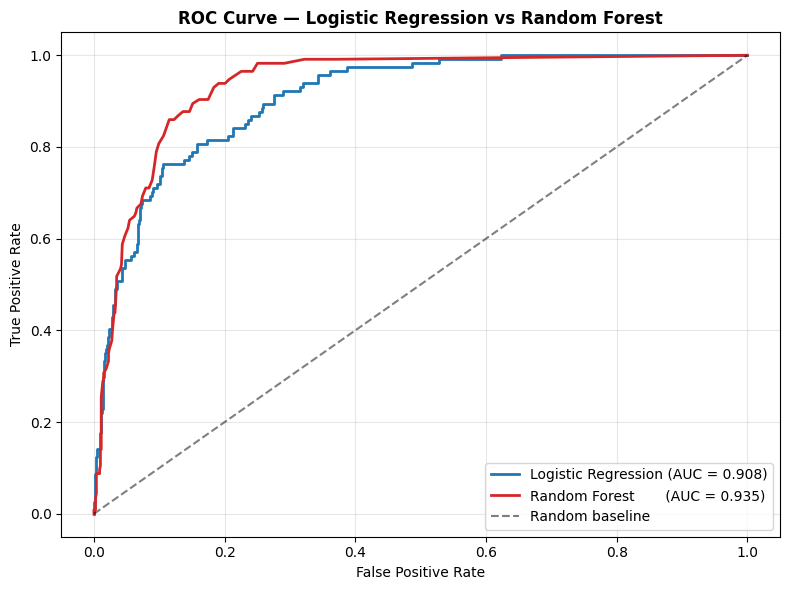

In [93]:
# Model comparison: LR vs RF
print("\n" + "=" * 55)
print("Model Comparison — Logistic Regression vs Random Forest")
print("=" * 55)
print(f"{'Metric':<20} {'Logistic Reg':>14} {'Random Forest':>14}")
print("─" * 50)
for label, lr_v, rf_v in [
    ("Accuracy",  lr_accuracy,   rf_accuracy),
    ("Precision", lr_precision,  rf_precision),
    ("Recall",    lr_recall,     rf_recall),
    ("F1 Score",  lr_f1,         rf_f1),
    ("ROC-AUC",   lr_roc_auc,    rf_roc_auc),
]:
    better = "← RF better" if rf_v > lr_v else ("← LR better" if lr_v > rf_v else "")
    print(f"  {label:<18} {lr_v:>14.4f} {rf_v:>14.4f}  {better}")

# ROC curves — both models on same axes
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, lw=2, color="#1f77b4",
         label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, lw=2, color="#d62728",
         label=f"Random Forest       (AUC = {rf_roc_auc:.3f})")
plt.plot([0,1],[0,1], "k--", alpha=0.5, label="Random baseline")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression vs Random Forest",
          fontweight="bold")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The model comparison reveals a clear and instructive split between the two models. Random Forest outperforms Logistic Regression on three metrics, achieving higher accuracy (0.899 versus 0.847), higher precision (0.662 versus 0.434), and a higher ROC-AUC (0.935 versus 0.908). Logistic Regression wins on the two remaining metrics, delivering substantially higher recall (0.772 versus 0.377) and a better F1 score (0.555 versus 0.480).
The ROC curve makes the overall picture clear. Random Forest sits consistently above Logistic Regression across all decision thresholds, confirming it is the stronger discriminator when both models are evaluated across the full probability range. An AUC of 0.935 versus 0.908 is a meaningful gap that reflects Random Forest's superior ability to rank churned customers above retained ones overall.

However, the recall gap tells the most important part of the story for practical deployment. At the default decision threshold of 0.5, Logistic Regression correctly identifies 77.2% of actual churners compared to just 37.7% for Random Forest. In business terms, Random Forest misses roughly 6 out of every 10 at-risk customers before they churn, a consequence that outweighs its advantages in accuracy and precision for this specific use case. The lower recall of Random Forest is largely a result of the class imbalance in the dataset, where even with class weighting applied, the model remains more conservative in predicting the minority class at the default threshold.

The recommended deployment model is **Logistic Regression** due to its substantially higher recall, which directly translates to more churners being flagged for proactive intervention. Random Forest remains valuable as a complementary analytical tool since its feature importance rankings provide a scale-invariant validation of the behavioural signals identified in Sections 2 and 3. Both models confirm that recency and purchase consistency are the dominant drivers of churn, fully consistent with the statistical findings from Section 3.


## Summary of Key Findings and Management Recommendations

### Overview

Across Sections 2, 3, and 4, the analysis of LuminaTech's customer data reveals a consistent and actionable picture of churn. The overall churn rate stands at 12.3%, representing 379 customers who did not return in 2024. Total revenue declined 9.2% year-on-year from \$84.9M to \$77.1M, and because revenue tracks
customer count almost perfectly, this decline is driven by losing customers and not by existing customers spending less. Retaining and reacquiring customers is therefore the single most impactful lever for revenue recovery.

---

### Finding 1 — Churn Risk Is Predictable Early from Behavioural Signals

The statistical tests in Section 3 and the prediction models in Section 4 consistently confirm that churned customers behave differently from retained customers well before they stop buying entirely.

Churned customers made their last purchase an average of 169 days before year-end, compared to just 34 days for retained customers. They were also active in a median of only 2 distinct months versus 12 for retained customers. These differences are statistically overwhelming (p values approaching zero in both
t-tests) and the prediction model correctly flags 77.2% of churners using these signals alone.

**Recommendation**<br>
Build an automated inactivity alert that flags any
previously active account that has not placed an order within 83 days. This threshold is data-derived from the 75th percentile of recency and historically captures 86.3% of customers who subsequently churn. The sales team should contact flagged accounts within 5 business days of the alert being triggered.

---

### Finding 2 — Purchase Habit Formation Is the Strongest Protective Factor

A customer who purchases across many months is structurally different from one who places a burst of orders in a single engagement window. Retained customers maintained a purchasing span of 340 days on average, while churned customers compressed all their activity into just 35 days. The Random Forest feature
importance chart independently ranked recency, tenure, and months active as the top three predictors, validating this finding without relying on statistical assumptions.

**Recommendation**<br>
Prioritise encouraging repeat purchases within the first 60 days of a new account. A customer who places a second or third order within that window is significantly more likely to form a recurring buying habit. Onboarding campaigns such as follow-up calls after a first order, tailored product recommendations, or early-repeat incentives are the highest-ROI retention investments available.

---

### Finding 3 — High-Spending Customers Are Not Low-Risk

The Section 3.3 t-test revealed a counterintuitive finding. Churned customers actually have a higher average transaction value than retained customers, meaning churn is not concentrated among low-value accounts. These customers appear to be project-driven buyers who place larger, infrequent orders for a specific job before exiting the relationship.

**Recommendation**<br>
Do not prioritise retention resources based on account spend alone. A high-value account with low order frequency and high recency is at elevated churn risk regardless of its total revenue contribution. Proactive contact during an active project, to understand upcoming pipeline and identify the next opportunity before the current engagement ends, is the most effective
strategy for converting project buyers into recurring accounts.

---

### Finding 4 — Churn Risk Is Geographically Concentrated

Churn is not evenly distributed across LuminaTech's territory. Adelaide shows the highest churn rate at 14.5%, followed by Melbourne at 13.1% and Sydney at 12.2%, all above the national average of 12.3%. At the other end, ACT/Riverina retains 97.5% of its customers, and Townsville retains 94.7%.

**Recommendation**<br>
A uniform national retention strategy is inefficient. The three above-average districts (Adelaide, Melbourne, Sydney) account for the majority of churned customers in absolute terms and require targeted intervention programmes. Management should also investigate the practices of ACT/Riverina and Townsville to understand what those teams are doing differently, as their
approaches may contain replicable lessons for higher-churn regions.

---

### Finding 5 — The Prediction Model Is Operationally Deployable

The Logistic Regression model achieves a ROC-AUC of 0.908 and correctly identifies 77.2% of actual churners, meaning it can flag at-risk customers before they leave with meaningful reliability. Random Forest achieves a higher AUC of 0.935 but captures only 37.7% of churners at the default threshold,
making it less suitable for front-line deployment.

**Recommendation**<br>
Deploy the Logistic Regression model as a monthly scoring
pipeline. Every active account should receive a churn probability score at the start of each month, and accounts crossing a defined risk threshold should be passed to the relevant district sales team for outreach. The model should be retrained quarterly as new transaction data becomes available to ensure the predictions remain calibrated to current customer behaviour.

### Authored by: Felicya Irenea, Monica Danielle Arucan, Nathania Asfa Aqilah, Ravelto Wangistu, Sadik Bajracharya, Zi Yin Wong